# Cohort-Level MEA Analysis Notebook (In-Notebook Configuration)

## Design Document

This notebook is designed to analyze **pipeline outputs across a cohort** (many runs and wells), with no external reference sheet required yet.
Everything is controlled in notebook config cells so you can iterate quickly.

### 1) Goals
- Discover all per-well outputs under a cohort root folder.
- Build reproducible, tidy tables at well-level and unit-level.
- Let you define groupings, DIV, assays, and optional outliers directly in notebook.
- Apply configurable filtering and aggregation before stats and plots.
- Export clean analysis artifacts (tables, figures, and logs).

### 2) Input Data Model (from pipeline)
Expected files per well:
- `network_results.json`
- `metrics_curated.xlsx` (fallback `qm_unfiltered.xlsx`)
- `tm_curated.xlsx` (fallback `tm_unfiltered.xlsx`)
- optional: `spike_times.npy`, `rejection_log.xlsx`

Path convention used for metadata parsing:
`<project>/<date>/<chip>/Network/<run_id>/<well_id>/...`

### 3) Notebook Stages
1. Configure cohort path and analysis options.
2. Discover files and parse metadata from paths.
3. Load network JSON and flatten burst metrics.
4. Load unit and template metric tables.
5. Apply manual annotations (group, DIV, assay, etc.).
6. Apply manual outliers and filtering rules.
7. Aggregate unit and template metrics to well-level.
8. Merge all well-level metrics.
9. Compute group summaries and statistical tests.
10. Generate figures and export outputs.

### 4) Manual Controls (for now)
- `manual_annotations`: define `group`, `DIV`, `assay`, etc.
- `manual_outliers`: exclude specific wells with reasons.
- `filters`: include and exclude groups, DIVs, assays, min units, etc.
- `aggregation`: choose method per metric (`mean`, `median`, `sem`, etc.).

### 5) Future Extension
Later, this notebook can switch to a reference file by replacing manual annotations with a metadata import step.
The remaining pipeline (filters -> aggregation -> stats -> export) stays unchanged.


## Quick Start
1. Edit `CONFIG['cohort_root']`.
2. Set experiment timing in `CONFIG['time_model']` (`div0_date`, `treatment_date`, `treatment_bin_size_days`).
3. Set normalization in `CONFIG['normalization']` (default: nearest pre-treatment bin per well; optional `baseline_start_div`).
4. Optionally select runs in `CONFIG['filters']` with `include_run_ids` / `exclude_run_ids`.
5. Fill `manual_annotations` (optional) and `manual_outliers` (optional).
6. Run all cells top-to-bottom.
7. Inspect `well_manifest`, `well_index`, `well_filtered`, normalization QC tables, and `exclusion_log`.
8. Tune filters, bin size, normalization baseline, and aggregation and rerun.


In [1]:
from __future__ import annotations

import itertools
import json
import math
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    from statannotations.Annotator import Annotator
except Exception:
    Annotator = None

pd.options.display.max_columns = 200
pd.options.display.width = 180
sns.set_theme(style='whitegrid', context='talk')


In [2]:
CONFIG = {
    'cohort_root': '/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138',
    'output_dir': './analysis_outputs',
    'file_patterns': {
        'network_json': 'network_results.json',
        'metrics_curated': 'metrics_curated.xlsx',
        'metrics_unfiltered': 'qm_unfiltered.xlsx',
        'tm_curated': 'tm_curated.xlsx',
        'tm_unfiltered': 'tm_unfiltered.xlsx',
        'spike_times': 'spike_times.npy',
        'rejection_log': 'rejection_log.xlsx',
    },
    'discovery': {
        'show_progress': True,
        'progress_update_every': 2000,
        'skip_dir_names': [
            'sorter_output',
            'analyzer_output',
            'preprocessed.zarr',
            'binary',
            'phy_output',
            '__pycache__',
            '.ipynb_checkpoints',
        ],
    },
    'time_model': {
        'div0_date': '2026-03-13',
        'treatment_date': '2026-03-25',
        'override_div_from_date': True,
        'treatment_day_phase': 'pre_treatment',
        'treatment_bin_size_days': 3,
        'pre_label': 'pre_treatment',
        'post_label': 'post_treatment',
    },
    'normalization': {
        'enabled': True,
        'method': 'ratio',
        'metric_suffix': '_ratio',
        'use_normalized_for_stats': True,
        'baseline_mode': 'nearest_pre_treatment_bin',
        'baseline_start_div': None,
        'baseline_agg': 'median',
        'epsilon': 1e-9,
        'track_key_columns': ['project', 'chip_id', 'well_id'],
        'metrics_to_normalize': None,
    },
    'plate_grouping': {
        'enabled': True,
        'layout': 'row_major',
        'n_rows': 4,
        'n_cols': 6,
        'overwrite_existing_group': True,
        'column_group_map': {
            1: 'NPH',
            2: 'IVH-E',
            3: 'IVH-L',
            4: 'CT',
            5: '20uM',
            6: '10uM',
        },
        'row_labels': {
            1: 'A',
            2: 'B',
            3: 'C',
            4: 'D',
        },
    },
    'manual_annotations': [
        # Example:
        # {'chip_id': 'M08018', 'run_id': '000021', 'well_id': 'well003', 'assay': 'Network today'},
    ],
    'manual_outliers': [
        {'well_id': 'well022', 'reason': 'Excluded: physical well #23 (1-based)'},
        # Example:
        # {'chip_id': 'M08020', 'run_id': '000024', 'well_id': 'well005', 'reason': 'Electrode drift'},
    ],
    'filters': {
        'exclude_manual_outliers': True,
        'drop_unknown_group': False,
        'allowed_groups': None,
        'allowed_assays': None,
        'allowed_divs': None,
        'allowed_treatment_phases': None,
        'allowed_time_bin_starts': None,
        'include_run_ids': None,  # e.g. [12, 14, '000016']
        'exclude_run_ids': None,  # e.g. [5, '000007']
        'min_units_network_json': 0,
        'require_network_json': True,
    },
    'aggregation': {
        'unit_to_well_default': 'median',
        'template_to_well_default': 'median',
        'group_summary_center': 'mean',
        'group_summary_error': 'sem',
        'unit_metric_methods': {
            'firing_rate': 'median',
            'amplitude_median': 'median',
            'presence_ratio': 'median',
            'rp_contamination': 'median',
            'snr': 'median',
            'loc_x': 'median',
            'loc_y': 'median',
        },
        'template_metric_methods': {
            'peak_to_valley': 'median',
            'peak_trough_ratio': 'median',
            'half_width': 'median',
            'repolarization_slope': 'median',
            'recovery_slope': 'median',
        },
    },
    'analysis': {
        'group_col': 'group',
        'x_col': 'time_bin_start_day',
        'x_label': 'Days since treatment (bin start day)',
        'metric_list': [
            'network_bursts_rate',
            'network_bursts_count',
            'network_bursts_duration_mean',
            'network_bursts_inter_event_interval_mean',
            'network_bursts_burst_peak_mean',
            'n_units_network_json',
            'unit_firing_rate',
            'unit_amplitude_median',
            'template_half_width',
            'template_recovery_slope',
        ],
        'group_order': ['NPH', 'IVH-E', 'IVH-L', 'CT', '20uM', '10uM'],
        'palette': None,
        'minimum_wells_per_group_for_stats': 2,
        'multiple_testing_correction': 'bh',
        'stats_alpha': 0.05,
        'legend': {
            'outside_right': True,
            'loc': 'upper left',
            'bbox_to_anchor': (1.02, 1.0),
            'ncol': 1,
            'frameon': False,
            'fontsize': 9,
            'title_fontsize': 10,
            'right_margin': 0.78,
        },
    },
    'stat_annotation': {
        'enabled': True,
        'reference_group': 'CT',
        'use_adjusted_p': True,
        'text_format': 'star',
        'loc': 'outside',
        'fontsize': 9,
    },
}

CONFIG


{'cohort_root': '/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138',
 'output_dir': './analysis_outputs',
 'file_patterns': {'network_json': 'network_results.json',
  'metrics_curated': 'metrics_curated.xlsx',
  'metrics_unfiltered': 'qm_unfiltered.xlsx',
  'tm_curated': 'tm_curated.xlsx',
  'tm_unfiltered': 'tm_unfiltered.xlsx',
  'spike_times': 'spike_times.npy',
  'rejection_log': 'rejection_log.xlsx'},
 'discovery': {'show_progress': True,
  'progress_update_every': 2000,
  'skip_dir_names': ['sorter_output',
   'analyzer_output',
   'preprocessed.zarr',
   'binary',
   'phy_output',
   '__pycache__',
   '.ipynb_checkpoints']},
 'time_model': {'div0_date': '2026-03-13',
  'treatment_date': '2026-03-25',
  'override_div_from_date': True,
  'treatment_day_phase': 'pre_treatment',
  'treatment_bin_size_days': 3,
  'pre_label': 'pre_treatment',
  'post_label': 'post_treatment'},
 'normalization': {'enabled': True,
  'method': 'ratio',
  'metric_suffix': '_ratio',
  'use_normalized_for_sta

In [3]:
KEY_COLS = ['project', 'date', 'chip_id', 'run_id', 'well_id']

_DEFAULT_SKIP_DIRS = {
    'sorter_output',
    'analyzer_output',
    'preprocessed.zarr',
    'binary',
    'phy_output',
    '__pycache__',
    '.ipynb_checkpoints',
}


def is_missing(value: Any) -> bool:
    if value is None:
        return True
    if isinstance(value, float) and math.isnan(value):
        return True
    text = str(value).strip()
    return text == '' or text.lower() == 'nan'


def normalize_run_id(value: Any) -> str | None:
    if is_missing(value):
        return None
    text = str(value).strip()
    digits = ''.join(ch for ch in text if ch.isdigit())
    if digits:
        return digits.zfill(6)
    return text


def normalize_well_id(value: Any) -> str | None:
    if is_missing(value):
        return None
    text = str(value).strip().lower()
    digits = ''.join(ch for ch in text if ch.isdigit())
    if digits:
        return f'well{int(digits):03d}'
    return text


def normalize_chip_id(value: Any) -> str | None:
    if is_missing(value):
        return None
    return str(value).strip().upper()


def normalize_date(value: Any) -> str | None:
    if is_missing(value):
        return None
    text = str(value).strip()
    digits = ''.join(ch for ch in text if ch.isdigit())
    if len(digits) == 8 and digits.startswith('20'):
        return digits[2:]
    return digits or text


def build_well_key(row: dict[str, Any]) -> str:
    values = [row.get(k) for k in KEY_COLS]
    return '|'.join('' if v is None else str(v) for v in values)


def parse_metadata_from_well_dir(well_dir: Path) -> dict[str, Any]:
    parts = list(well_dir.parts)
    project = date = chip_id = run_id = well_id = None

    if 'Network' in parts:
        idx = max(i for i, p in enumerate(parts) if p == 'Network')
        if idx - 3 >= 0:
            project = parts[idx - 3]
        if idx - 2 >= 0:
            date = parts[idx - 2]
        if idx - 1 >= 0:
            chip_id = parts[idx - 1]
        if idx + 1 < len(parts):
            run_id = parts[idx + 1]
        if idx + 2 < len(parts):
            well_id = parts[idx + 2]

    if well_id is None and len(parts) >= 1:
        well_id = parts[-1]
    if run_id is None and len(parts) >= 2:
        run_id = parts[-2]
    if chip_id is None and len(parts) >= 3:
        chip_id = parts[-3]
    if date is None and len(parts) >= 4:
        date = parts[-4]
    if project is None and len(parts) >= 5:
        project = parts[-5]

    record = {
        'project': str(project) if project is not None else None,
        'date': normalize_date(date),
        'chip_id': normalize_chip_id(chip_id),
        'run_id': normalize_run_id(run_id),
        'well_id': normalize_well_id(well_id),
        'well_dir': str(well_dir),
    }
    record['well_key'] = build_well_key(record)
    return record


def normalize_key_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'project' in out.columns:
        out['project'] = out['project'].astype(str).str.strip()
    if 'date' in out.columns:
        out['date'] = out['date'].apply(normalize_date)
    if 'chip_id' in out.columns:
        out['chip_id'] = out['chip_id'].apply(normalize_chip_id)
    if 'run_id' in out.columns:
        out['run_id'] = out['run_id'].apply(normalize_run_id)
    if 'well_id' in out.columns:
        out['well_id'] = out['well_id'].apply(normalize_well_id)
    if set(KEY_COLS).issubset(set(out.columns)):
        out['well_key'] = out.apply(lambda r: build_well_key(r.to_dict()), axis=1)
    return out


def discover_pipeline_outputs(
    cohort_root: str,
    file_patterns: dict[str, str],
    show_progress: bool = True,
    skip_dir_names: list[str] | set[str] | None = None,
    progress_update_every: int = 2000,
) -> pd.DataFrame:
    root = Path(cohort_root).expanduser().resolve()
    if not root.exists():
        raise FileNotFoundError(f'Cohort root does not exist: {root}')

    skip_names = set(skip_dir_names) if skip_dir_names is not None else set(_DEFAULT_SKIP_DIRS)

    filename_to_labels: dict[str, list[str]] = {}
    for label, filename in file_patterns.items():
        filename_to_labels.setdefault(str(filename), []).append(label)
    target_filenames = set(filename_to_labels)

    records: dict[str, dict[str, Any]] = {}
    scanned_dirs = 0
    matched_files = 0

    use_tqdm = bool(show_progress and tqdm is not None)
    pbar = tqdm(desc='Scanning directories', unit='dir', dynamic_ncols=True) if use_tqdm else None

    for dirpath, dirnames, filenames in os.walk(str(root), topdown=True):
        dirnames[:] = [d for d in dirnames if d not in skip_names and not d.endswith('.zarr')]

        scanned_dirs += 1
        if pbar is not None:
            pbar.update(1)
        elif show_progress and scanned_dirs % progress_update_every == 0:
            print(f'  scanned {scanned_dirs:,} dirs | wells found {len(records):,} | matched files {matched_files:,}')

        if not filenames:
            continue

        hits = target_filenames.intersection(filenames)
        if not hits:
            continue

        well_dir = Path(dirpath)
        key = str(well_dir)
        entry = records.get(key)
        if entry is None:
            entry = parse_metadata_from_well_dir(well_dir)
            records[key] = entry

        for hit_name in hits:
            path_str = str(well_dir / hit_name)
            for label in filename_to_labels[hit_name]:
                entry[label] = path_str
            matched_files += 1

        if pbar is not None and scanned_dirs % progress_update_every == 0:
            pbar.set_postfix(wells=len(records), matches=matched_files)

    if pbar is not None:
        pbar.set_postfix(wells=len(records), matches=matched_files)
        pbar.close()

    if show_progress:
        print(f'Scanned {scanned_dirs:,} directories, found {len(records):,} wells, matched {matched_files:,} files.')

    manifest = pd.DataFrame(records.values())
    if manifest.empty:
        return manifest

    for label in file_patterns:
        if label not in manifest.columns:
            manifest[label] = pd.NA
        manifest[f'has_{label}'] = manifest[label].notna()

    manifest = normalize_key_columns(manifest)
    sort_cols = [c for c in KEY_COLS if c in manifest.columns]
    manifest = manifest.sort_values(sort_cols).drop_duplicates(subset=['well_key']).reset_index(drop=True)
    return manifest


def choose_existing_path(row: pd.Series, preferred_col: str, fallback_col: str) -> tuple[Path | None, str | None]:
    for col in [preferred_col, fallback_col]:
        value = row.get(col)
        if isinstance(value, str) and value.strip() != '':
            p = Path(value)
            if p.exists():
                return p, col
    return None, None


In [4]:
import time

_discovery_cfg = CONFIG.get('discovery', {})
_t0 = time.perf_counter()

well_manifest = discover_pipeline_outputs(
    CONFIG['cohort_root'],
    CONFIG['file_patterns'],
    show_progress=_discovery_cfg.get('show_progress', True),
    skip_dir_names=_discovery_cfg.get('skip_dir_names'),
    progress_update_every=int(_discovery_cfg.get('progress_update_every', 2000)),
)

_elapsed = time.perf_counter() - _t0
print(f'Discovery completed in {_elapsed:.1f} seconds.')

if well_manifest.empty:
    raise RuntimeError("No pipeline outputs discovered. Update CONFIG['cohort_root'] or check file patterns.")

print(f'Discovered wells: {len(well_manifest)}')
display(well_manifest.head(10))

availability_cols = [c for c in well_manifest.columns if c.startswith('has_')]
availability_pct = well_manifest[availability_cols].mean().mul(100).round(1).rename('pct_wells')
print()
print('File availability (% wells):')
display(availability_pct.to_frame())


Scanning directories: 0dir [00:00, ?dir/s]

Scanned 922 directories, found 432 wells, matched 3,020 files.
Discovery completed in 1.3 seconds.
Discovered wells: 432


,project,date,chip_id,run_id,well_id,well_dir,well_key,metrics_unfiltered,network_json,tm_curated,spike_times,tm_unfiltered,rejection_log,metrics_curated,has_network_json,has_metrics_curated,has_metrics_unfiltered,has_tm_curated,has_tm_unfiltered,has_spike_times,has_rejection_log
0,CX138,260319,T003346,000004,well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
1,CX138,260319,T003346,000004,well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
2,CX138,260319,T003346,000004,well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
3,CX138,260319,T003346,000004,well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
4,CX138,260319,T003346,000004,well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
5,CX138,260319,T003346,000004,well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
6,CX138,260319,T003346,000004,well006,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well006,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True
7,CX138,260319,T003346,000004,well007,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well007,/mnt/benshalom-nas/analysis/Sade


File availability (% wells):


,pct_wells
has_network_json,99.5
has_metrics_curated,100.0
has_metrics_unfiltered,100.0
has_tm_curated,100.0
has_tm_unfiltered,100.0
has_spike_times,99.5
has_rejection_log,100.0


In [5]:
EVENT_LEVELS = ('burstlets', 'network_bursts', 'superbursts')
STAT_BLOCKS = (
    'duration',
    'inter_event_interval',
    'intensity',
    'participation',
    'spikes_per_burst',
    'burst_peak',
    'peak_synchrony',
)
STAT_FIELDS = ('mean', 'std', 'cv')


def flatten_network_result(payload: dict[str, Any]) -> dict[str, Any]:
    flat: dict[str, Any] = {}
    flat['n_units_network_json'] = payload.get('n_units', np.nan)

    for level in EVENT_LEVELS:
        level_block = payload.get(level, {}) if isinstance(payload, dict) else {}
        events = level_block.get('events', []) if isinstance(level_block, dict) else []
        metrics = level_block.get('metrics', {}) if isinstance(level_block, dict) else {}

        flat[f'{level}_events_len'] = len(events) if isinstance(events, list) else np.nan
        flat[f'{level}_count'] = metrics.get('count', np.nan)
        flat[f'{level}_rate'] = metrics.get('rate', np.nan)

        for block in STAT_BLOCKS:
            block_dict = metrics.get(block, {}) if isinstance(metrics, dict) else {}
            for field in STAT_FIELDS:
                flat[f'{level}_{block}_{field}'] = block_dict.get(field, np.nan)

    diagnostics = payload.get('diagnostics', {}) if isinstance(payload, dict) else {}
    for key, value in diagnostics.items():
        flat[f'diag_{key}'] = value

    plot_data = payload.get('plot_data', {}) if isinstance(payload, dict) else {}
    flat['plot_threshold'] = plot_data.get('threshold', np.nan)
    flat['plot_baseline'] = plot_data.get('baseline', np.nan)

    t = plot_data.get('t', None)
    if isinstance(t, list) and len(t) > 1:
        flat['recording_duration_s_plot'] = float(t[-1] - t[0])
    else:
        flat['recording_duration_s_plot'] = np.nan

    return flat


def load_network_metrics(manifest_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    errors = []

    for _, row in manifest_df.iterrows():
        path = row.get('network_json')
        if not isinstance(path, str) or path.strip() == '':
            continue

        try:
            payload = json.loads(Path(path).read_text())
            flat = flatten_network_result(payload)
        except Exception as exc:
            errors.append({'well_key': row['well_key'], 'path': path, 'error': str(exc)})
            continue

        base = {k: row.get(k) for k in KEY_COLS + ['well_key', 'well_dir', 'network_json']}
        rows.append({**base, **flat})

    return pd.DataFrame(rows), pd.DataFrame(errors)


network_metrics_well, network_load_errors = load_network_metrics(well_manifest)
print(f'Loaded network JSON rows: {len(network_metrics_well)}')
if not network_load_errors.empty:
    print(f'Network JSON load errors: {len(network_load_errors)}')
    display(network_load_errors.head(10))
display(network_metrics_well.head(5))


Loaded network JSON rows: 430


,project,date,chip_id,run_id,well_id,well_key,well_dir,network_json,n_units_network_json,burstlets_events_len,burstlets_count,burstlets_rate,burstlets_duration_mean,burstlets_duration_std,burstlets_duration_cv,burstlets_inter_event_interval_mean,burstlets_inter_event_interval_std,burstlets_inter_event_interval_cv,burstlets_intensity_mean,burstlets_intensity_std,burstlets_intensity_cv,burstlets_participation_mean,burstlets_participation_std,burstlets_participation_cv,burstlets_spikes_per_burst_mean,burstlets_spikes_per_burst_std,burstlets_spikes_per_burst_cv,burstlets_burst_peak_mean,burstlets_burst_peak_std,burstlets_burst_peak_cv,burstlets_peak_synchrony_mean,burstlets_peak_synchrony_std,burstlets_peak_synchrony_cv,network_bursts_events_len,network_bursts_count,network_bursts_rate,network_bursts_duration_mean,network_bursts_duration_std,network_bursts_duration_cv,network_bursts_inter_event_interval_mean,network_bursts_inter_event_interval_std,network_bursts_inter_event_interval_cv,network_bursts_intensity_mean,network_bursts_intensity_std,network_bursts_intensity_cv,network_bursts_participation_mean,network_bursts_participation_std,network_bursts_participation_cv,network_bursts_spikes_per_burst_mean,network_bursts_spikes_per_burst_std,network_bursts_spikes_per_burst_cv,network_bursts_burst_peak_mean,network_bursts_burst_peak_std,network_bursts_burst_peak_cv,network_bursts_peak_synchrony_mean,network_bursts_peak_synchrony_std,network_bursts_peak_synchrony_cv,superbursts_events_len,superbursts_count,superbursts_rate,superbursts_duration_mean,superbursts_duration_std,superbursts_duration_cv,superbursts_inter_event_interval_mean,superbursts_inter_event_interval_std,superbursts_inter_event_interval_cv,superbursts_intensity_mean,superbursts_intensity_std,superbursts_intensity_cv,superbursts_participation_mean,superbursts_participation_std,superbursts_participation_cv,superbursts_spikes_per_burst_mean,superbursts_spikes_per_burst_std,superbursts_spikes_per_burst_cv,superbursts_burst_peak_mean,superbursts_burst_peak_std,superbursts_burst_peak_cv,superbursts_peak_synchrony_mean,superbursts_peak_synchrony_std,superbursts_peak_synchrony_cv,diag_adaptive_bin_ms,diag_biological_isi_s,diag_baseline_value,diag_spread_mad,diag_participation_quorum_floor,diag_threshold_detect_1.2x,diag_threshold_merge_1.05x,diag_burstlet_merge_gap_s,diag_network_merge_gap_s,diag_merge_floor,plot_threshold,plot_baseline,recording_duration_s_plot
0,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,77,2,2.0,0.006666,0.450000,0.090000,0.200000,129.840000,0.000000,0.000000,3.933798,0.550048,0.139826,0.506494,0.012987,0.025641,140.500000,20.500000,0.145907,483.333333,16.666667,0.034483,10.361601,0.213031,0.020560,2,2.0,0.006666,0.450000,0.090000,0.200000,129.8400,0.000000,0.000000,3.933798,0.550048,0.139826,0.506494,0.012987,0.025641,140.500000,20.500000,0.145907,483.333333,16.666667,0.034483,10.361601,0.213031,0.020560,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,0.1159,1.544798,0.730851,10.0,10.0,1.622038,0.3477,1.159,1.622038,10.0,1.544798,300.03
1,CX138,260319,T003346,000004,well001,CX138|260319|T003346|000004|well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,154,26,26.0,0.086657,0.541154,0.304521,0.562726,10.724400,19.942545,1.859549,7.821351,6.089849,0.778619,0.516733,0.153930,0.297890,270.230769,217.744259,0.805772,748.717949,232.458207,0.310475,16.078538,5.909465,0.367537,7,7.0,0.023331,2.091429,0.891490,0.426259,44.6850,17.354412,0.388372,29.050731,16.034657,0.551954,0.524521,0.096276,0.183550,1003.714286,548.090898,0.546063,947.619048,266.581619,0.281317,20.486693,6.877201,0.335691,3,3.0,0.009999,2.890,0.203961,0.070575,72.18,14.850000,0.205736,44.210618,2.318002,0.052431,0.572511,0.030393,0.053087,1519.00,70.289876,0.046274,

In [6]:
def sanitize_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'unit_id' not in out.columns:
        for candidate in ['Unnamed: 0', 'Unnamed: 0.1', 'index']:
            if candidate in out.columns:
                out = out.rename(columns={candidate: 'unit_id'})
                break
    return out


def load_metric_table(
    manifest_df: pd.DataFrame,
    preferred_col: str,
    fallback_col: str,
    table_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tables = []
    errors = []

    for _, row in manifest_df.iterrows():
        path, source_col = choose_existing_path(row, preferred_col, fallback_col)
        if path is None:
            continue

        try:
            df = pd.read_excel(path)
            df = sanitize_metric_table(df)
        except Exception as exc:
            errors.append({
                'well_key': row['well_key'],
                'path': str(path),
                'table_name': table_name,
                'error': str(exc),
            })
            continue

        for col in KEY_COLS + ['well_key', 'well_dir']:
            df[col] = row.get(col)
        df['source_path'] = str(path)
        df['source_type'] = source_col
        df['table_name'] = table_name
        tables.append(df)

    if tables:
        merged = pd.concat(tables, axis=0, ignore_index=True, sort=False)
    else:
        merged = pd.DataFrame()

    return merged, pd.DataFrame(errors)


unit_metrics_raw, unit_load_errors = load_metric_table(
    well_manifest,
    preferred_col='metrics_curated',
    fallback_col='metrics_unfiltered',
    table_name='quality_metrics',
)

template_metrics_raw, template_load_errors = load_metric_table(
    well_manifest,
    preferred_col='tm_curated',
    fallback_col='tm_unfiltered',
    table_name='template_metrics',
)

print(f'Unit-level rows loaded: {len(unit_metrics_raw)}')
print(f'Template-level rows loaded: {len(template_metrics_raw)}')

if not unit_load_errors.empty:
    print(f'Unit metric load errors: {len(unit_load_errors)}')
    display(unit_load_errors.head(10))

if not template_load_errors.empty:
    print(f'Template metric load errors: {len(template_load_errors)}')
    display(template_load_errors.head(10))

display(unit_metrics_raw.head(5))
display(template_metrics_raw.head(5))


/tmp/ipykernel_2009788/4092934553.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(tables, axis=0, ignore_index=True, sort=False)


Unit-level rows loaded: 44639
Template-level rows loaded: 44639


/tmp/ipykernel_2009788/4092934553.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(tables, axis=0, ignore_index=True, sort=False)


,unit_id,num_spikes,firing_rate,presence_ratio,snr,isi_violations_ratio,isi_violations_count,rp_contamination,rp_violations,sliding_rp_violation,amplitude_cutoff,amplitude_median,amplitude_cv_median,amplitude_cv_range,sync_spike_2,sync_spike_4,sync_spike_8,firing_range,sd_ratio,noise_cutoff,noise_ratio,loc_x,loc_y,project,date,chip_id,run_id,well_id,well_key,well_dir,source_path,source_type,table_name
0,1,160,0.533262,1.0,5.214650,0.0,0,0.0,0,NaN,NaN,-44.059753,NaN,NaN,0.043750,0.0,0.0,1.8,2.033205,-0.135622,0.021212,157.5,665.0,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,metrics_curated,quality_metrics
1,2,67,0.223304,1.0,7.187848,0.0,0,0.0,0,NaN,NaN,-62.942505,NaN,NaN,0.014925,0.0,0.0,0.8,3.897976,-0.107984,0.045455,157.5,1050.0,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,metrics_curated,quality_metrics
2,3,147,0.489935,1.0,4.193769,0.0,0,0.0,0,NaN,NaN,-31.471252,NaN,NaN,0.034014,0.0,0.0,1.2,0.980258,-0.228398,0.002899,52.5,1190.0,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,metrics_curated,quality_metrics
3,4,232,0.773230,1.0,3.357911,0.0,0,0.0,0,NaN,NaN,-25.177002,NaN,NaN,0.012931,0.0,0.0,2.0,0.969616,-0.189162,0.001852,105.0,1242.5,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,metrics_curated,quality_metrics
4,5,106,0.353286,1.0,3.856046,0.0,0,0.0,0,NaN,NaN,-31.471252,NaN,NaN,0.018868,0.0,0.0,0.8,0.775177,-0.158850,0.003333,105.0,1592.5,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,metrics_curated,quality_metrics


,unit_id,peak_to_valley,peak_trough_ratio,half_width,repolarization_slope,recovery_slope,num_positive_peaks,num_negative_peaks,project,date,chip_id,run_id,well_id,well_key,well_dir,source_path,source_type,table_name
0,1,0.00070,-0.256000,0.00030,143164.928820,-13824.801475,2,1,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,tm_curated,template_metrics
1,2,0.00069,-0.191070,0.00024,266203.781652,-13640.889242,1,1,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,tm_curated,template_metrics
2,3,0.00068,-0.177137,0.00021,161902.547609,-8254.166368,0,1,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,tm_curated,template_metrics
3,4,0.00062,-0.226735,0.00028,124156.330068,-7842.457301,2,1,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,tm_curated,template_metrics
4,5,0.00050,-0.203815,0.00022,164556.689251,-5155.778226,1,1,CX138,260319,T003346,000004,well000,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,tm_curated,template_metrics


In [7]:
def apply_manual_annotations(
    target_df: pd.DataFrame,
    rules_df: pd.DataFrame,
    key_cols: list[str] = KEY_COLS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    annotated = target_df.copy()
    if rules_df.empty:
        report = pd.DataFrame(columns=['rule_index', 'matched_rows', 'keys_used'])
        return annotated, report

    rules = normalize_key_columns(rules_df)
    value_cols = [c for c in rules.columns if c not in key_cols + ['well_key']]

    report_rows = []
    for ridx, rule in rules.iterrows():
        mask = pd.Series(True, index=annotated.index)
        used_keys = []

        for key in key_cols:
            if key not in rules.columns or key not in annotated.columns:
                continue
            value = rule.get(key)
            if is_missing(value):
                continue
            mask &= annotated[key].astype(str) == str(value)
            used_keys.append(key)

        if not used_keys:
            continue

        matched = int(mask.sum())
        if matched > 0:
            for col in value_cols:
                value = rule.get(col)
                if is_missing(value):
                    continue
                annotated.loc[mask, col] = value

        report_rows.append({
            'rule_index': ridx,
            'matched_rows': matched,
            'keys_used': ','.join(used_keys),
        })

    return annotated, pd.DataFrame(report_rows)


def mark_manual_outliers(
    target_df: pd.DataFrame,
    outlier_rules_df: pd.DataFrame,
    key_cols: list[str] = KEY_COLS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    marked = target_df.copy()
    marked['is_manual_outlier'] = False
    marked['manual_outlier_reason'] = pd.NA

    if outlier_rules_df.empty:
        report = pd.DataFrame(columns=['rule_index', 'matched_rows', 'keys_used', 'reason'])
        return marked, report

    rules = normalize_key_columns(outlier_rules_df)
    report_rows = []

    for ridx, rule in rules.iterrows():
        mask = pd.Series(True, index=marked.index)
        used_keys = []

        for key in key_cols:
            if key not in rules.columns or key not in marked.columns:
                continue
            value = rule.get(key)
            if is_missing(value):
                continue
            mask &= marked[key].astype(str) == str(value)
            used_keys.append(key)

        if not used_keys:
            continue

        reason = rule.get('reason', f'manual_outlier_rule_{ridx}')
        matched = int(mask.sum())

        if matched > 0:
            existing = marked.loc[mask, 'manual_outlier_reason'].fillna('')
            appended = np.where(existing == '', str(reason), existing + '; ' + str(reason))
            marked.loc[mask, 'manual_outlier_reason'] = appended
            marked.loc[mask, 'is_manual_outlier'] = True

        report_rows.append({
            'rule_index': ridx,
            'matched_rows': matched,
            'keys_used': ','.join(used_keys),
            'reason': reason,
        })

    return marked, pd.DataFrame(report_rows)


manual_annotations_df = pd.DataFrame(CONFIG['manual_annotations'])
manual_outliers_df = pd.DataFrame(CONFIG['manual_outliers'])

well_index = well_manifest.copy()
well_index = normalize_key_columns(well_index)

if not network_metrics_well.empty:
    net_units = network_metrics_well[['well_key', 'n_units_network_json']].drop_duplicates(subset=['well_key'])
    well_index = well_index.merge(net_units, on='well_key', how='left')

well_index, annotation_report = apply_manual_annotations(well_index, manual_annotations_df)
well_index, outlier_report = mark_manual_outliers(well_index, manual_outliers_df)

if 'group' not in well_index.columns:
    well_index['group'] = 'Unknown'
else:
    well_index['group'] = well_index['group'].fillna('Unknown').astype(str)

if 'DIV' in well_index.columns:
    well_index['DIV'] = pd.to_numeric(well_index['DIV'], errors='coerce')

print('Annotation rule matches:')
display(annotation_report if not annotation_report.empty else pd.DataFrame({'info': ['No manual annotations applied']}))

print('Outlier rule matches:')
display(outlier_report if not outlier_report.empty else pd.DataFrame({'info': ['No manual outliers applied']}))

display(well_index.head(10))


Annotation rule matches:


,info
0,No manual annotations applied


Outlier rule matches:


,rule_index,matched_rows,keys_used,reason
0,0,18,well_id,Excluded: physical well #23 (1-based)


,project,date,chip_id,run_id,well_id,well_dir,well_key,metrics_unfiltered,network_json,tm_curated,spike_times,tm_unfiltered,rejection_log,metrics_curated,has_network_json,has_metrics_curated,has_metrics_unfiltered,has_tm_curated,has_tm_unfiltered,has_spike_times,has_rejection_log,n_units_network_json,is_manual_outlier,manual_outlier_reason,group
0,CX138,260319,T003346,000004,well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,77.0,False,<NA>,Unknown
1,CX138,260319,T003346,000004,well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,154.0,False,<NA>,Unknown
2,CX138,260319,T003346,000004,well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,126.0,False,<NA>,Unknown
3,CX138,260319,T003346,000004,well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,135.0,False,<NA>,Unknown
4,CX138,260319,T003346,000004,well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,106.0,False,<NA>,Unknown
5,CX138,260319,T003346,000004,well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,94.0,False,<NA>,Unknown
6,CX138,260319,T003346,000004,well006,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well006,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysi

In [8]:
plate_cfg = CONFIG.get('plate_grouping', {})

if plate_cfg.get('enabled', True):
    n_rows = int(plate_cfg.get('n_rows', 4))
    n_cols = int(plate_cfg.get('n_cols', 6))
    layout = str(plate_cfg.get('layout', 'row_major')).strip().lower()
    overwrite_existing_group = bool(plate_cfg.get('overwrite_existing_group', True))

    raw_col_map = plate_cfg.get('column_group_map', {})
    column_group_map = {int(k): str(v) for k, v in raw_col_map.items()}

    raw_row_labels = plate_cfg.get('row_labels', {})
    row_labels = {int(k): str(v) for k, v in raw_row_labels.items()} if raw_row_labels else {
        i + 1: chr(ord('A') + i) for i in range(n_rows)
    }

    def _well_to_index(well_id: Any) -> int | None:
        if is_missing(well_id):
            return None
        digits = ''.join(ch for ch in str(well_id) if ch.isdigit())
        if not digits:
            return None
        return int(digits)

    def _index_to_row_col(idx: int | None) -> tuple[float, float]:
        if idx is None:
            return (np.nan, np.nan)
        if idx < 0 or idx >= (n_rows * n_cols):
            return (np.nan, np.nan)

        if layout == 'row_major':
            row = (idx // n_cols) + 1
            col = (idx % n_cols) + 1
        elif layout == 'column_major':
            col = (idx // n_rows) + 1
            row = (idx % n_rows) + 1
        else:
            raise ValueError("plate_grouping.layout must be 'row_major' or 'column_major'")
        return (row, col)

    def _to_plate_well_label(row_val: float, col_val: float) -> Any:
        if pd.isna(row_val) or pd.isna(col_val):
            return pd.NA
        row_int = int(row_val)
        col_int = int(col_val)
        row_letter = row_labels.get(row_int, str(row_int))
        return f'{row_letter}{col_int}'

    parsed_index = well_index['well_id'].apply(_well_to_index)
    row_col = parsed_index.apply(_index_to_row_col)

    well_index['plate_index_0based'] = parsed_index
    well_index['plate_row'] = row_col.apply(lambda rc: rc[0])
    well_index['plate_col'] = row_col.apply(lambda rc: rc[1])
    well_index['plate_well'] = well_index.apply(lambda r: _to_plate_well_label(r['plate_row'], r['plate_col']), axis=1)

    well_index['group_from_plate_col'] = well_index['plate_col'].apply(
        lambda c: column_group_map.get(int(c), pd.NA) if pd.notna(c) else pd.NA
    )

    if overwrite_existing_group or 'group' not in well_index.columns:
        well_index['group'] = well_index['group_from_plate_col']
    else:
        missing_mask = well_index['group'].isna() | (well_index['group'].astype(str).str.strip() == '')
        well_index.loc[missing_mask, 'group'] = well_index.loc[missing_mask, 'group_from_plate_col']

    well_index['group'] = well_index['group'].fillna('Unknown').astype(str)

    if CONFIG.get('analysis', {}).get('group_order') is None and column_group_map:
        CONFIG['analysis']['group_order'] = [column_group_map[c] for c in sorted(column_group_map)]

    print('Applied plate-column grouping.')
    print(f"Layout: {layout} | rows={n_rows} cols={n_cols}")
    display(
        well_index[
            ['well_id', 'plate_well', 'plate_row', 'plate_col', 'group_from_plate_col', 'group']
        ].drop_duplicates().sort_values('well_id').head(30)
    )

    print('Wells per group:')
    display(well_index.groupby('group', dropna=False)['well_key'].nunique().rename('n_wells').sort_values(ascending=False).to_frame())
else:
    print('plate_grouping disabled. Keeping group values from manual annotations/defaults.')


Applied plate-column grouping.
Layout: row_major | rows=4 cols=6


,well_id,plate_well,plate_row,plate_col,group_from_plate_col,group
0,well000,A1,1,1,NPH,NPH
1,well001,A2,1,2,IVH-E,IVH-E
2,well002,A3,1,3,IVH-L,IVH-L
3,well003,A4,1,4,CT,CT
4,well004,A5,1,5,20uM,20uM
5,well005,A6,1,6,10uM,10uM
6,well006,B1,2,1,NPH,NPH
7,well007,B2,2,2,IVH-E,IVH-E
8,well008,B3,2,3,IVH-L,IVH-L
9,well009,B4,2,4,CT,CT


Wells per group:


,n_wells
group,
10uM,72
20uM,72
CT,72
IVH-E,72
IVH-L,72
NPH,72


In [9]:
time_cfg = CONFIG.get('time_model', {})

div0_date = pd.to_datetime(time_cfg.get('div0_date', '2026-03-13'))
treatment_date = pd.to_datetime(time_cfg.get('treatment_date', '2026-03-25'))
override_div_from_date = bool(time_cfg.get('override_div_from_date', True))
bin_size_days = int(time_cfg.get('treatment_bin_size_days', 3))
pre_label = str(time_cfg.get('pre_label', 'pre_treatment'))
post_label = str(time_cfg.get('post_label', 'post_treatment'))
treatment_day_phase = str(time_cfg.get('treatment_day_phase', 'post_treatment')).strip().lower()

if bin_size_days <= 0:
    raise ValueError('time_model.treatment_bin_size_days must be > 0')


def parse_recording_date(value: Any) -> pd.Timestamp:
    if is_missing(value):
        return pd.NaT

    text = str(value).strip()
    digits = ''.join(ch for ch in text if ch.isdigit())

    candidates: list[tuple[str, str | None]] = []
    if len(digits) == 6:
        candidates.append((digits, '%y%m%d'))
    if len(digits) == 8 and digits.startswith('20'):
        candidates.append((digits, '%Y%m%d'))
    candidates.append((text, None))

    for raw, fmt in candidates:
        try:
            if fmt is None:
                ts = pd.to_datetime(raw, errors='raise')
            else:
                ts = pd.to_datetime(raw, format=fmt, errors='raise')
            if pd.notna(ts):
                return pd.Timestamp(ts).normalize()
        except Exception:
            continue

    return pd.NaT


def format_treatment_bin(start_day: Any, end_day: Any) -> Any:
    if pd.isna(start_day) or pd.isna(end_day):
        return pd.NA
    return f"D{int(start_day):+d} to D{int(end_day):+d}"


well_index['recording_date'] = well_index['date'].apply(parse_recording_date)
well_index['recording_date_str'] = well_index['recording_date'].dt.strftime('%Y-%m-%d')

computed_div = (well_index['recording_date'] - div0_date).dt.days
if override_div_from_date or 'DIV' not in well_index.columns:
    well_index['DIV'] = computed_div
else:
    well_index['DIV'] = pd.to_numeric(well_index['DIV'], errors='coerce')
    fill_mask = well_index['DIV'].isna()
    well_index.loc[fill_mask, 'DIV'] = computed_div.loc[fill_mask]
well_index['DIV'] = pd.to_numeric(well_index['DIV'], errors='coerce')

well_index['days_since_treatment'] = (well_index['recording_date'] - treatment_date).dt.days

phase = pd.Series(pd.NA, index=well_index.index, dtype='object')
valid_days = well_index['days_since_treatment'].notna()
if treatment_day_phase in {'pre', 'pre_treatment'}:
    phase.loc[valid_days] = np.where(
        well_index.loc[valid_days, 'days_since_treatment'] <= 0,
        pre_label,
        post_label,
    )
else:
    phase.loc[valid_days] = np.where(
        well_index.loc[valid_days, 'days_since_treatment'] < 0,
        pre_label,
        post_label,
    )
well_index['treatment_phase'] = phase

days_numeric = pd.to_numeric(well_index['days_since_treatment'], errors='coerce')
raw_bin_idx = np.floor(days_numeric / bin_size_days)
well_index['time_bin_index'] = pd.Series(raw_bin_idx, index=well_index.index).astype('Int64')
well_index.loc[days_numeric.isna(), 'time_bin_index'] = pd.NA
well_index['time_bin_start_day'] = (well_index['time_bin_index'] * bin_size_days).astype('Int64')
well_index['time_bin_end_day'] = (well_index['time_bin_start_day'] + (bin_size_days - 1)).astype('Int64')
well_index['time_bin_center_day'] = pd.to_numeric(well_index['time_bin_start_day'], errors='coerce') + ((bin_size_days - 1) / 2.0)
well_index['time_bin_label'] = well_index.apply(
    lambda r: format_treatment_bin(r['time_bin_start_day'], r['time_bin_end_day']),
    axis=1,
)

parse_fail_count = int(well_index['recording_date'].isna().sum())
print(f"Time model applied | DIV0={div0_date.date()} | treatment={treatment_date.date()} | bin={bin_size_days} day(s)")
print(f"Rows with unparsed recording date: {parse_fail_count}")

preview_cols = [
    c for c in [
        'date',
        'recording_date_str',
        'DIV',
        'days_since_treatment',
        'treatment_phase',
        'time_bin_start_day',
        'time_bin_end_day',
        'time_bin_label',
    ]
    if c in well_index.columns
]
display(well_index[preview_cols + ['well_id']].drop_duplicates().sort_values(['recording_date_str', 'well_id']).head(30))

print('Wells per treatment bin:')
bin_summary = (
    well_index.groupby(['time_bin_start_day', 'time_bin_end_day', 'time_bin_label'], dropna=False)['well_key']
    .nunique()
    .rename('n_wells')
    .reset_index()
    .sort_values('time_bin_start_day')
)
display(bin_summary)


Time model applied | DIV0=2026-03-13 | treatment=2026-03-25 | bin=3 day(s)
Rows with unparsed recording date: 0


,date,recording_date_str,DIV,days_since_treatment,treatment_phase,time_bin_start_day,time_bin_end_day,time_bin_label,well_id
0,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well000
1,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well001
2,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well002
3,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well003
4,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well004
5,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well005
6,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well006
7,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well007
8,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well008
9,260319,2026-03-19,6,-6,pre_treatment,-6,-4,D-6 to D-4,well009


Wells per treatment bin:


,time_bin_start_day,time_bin_end_day,time_bin_label,n_wells
0,-6,-4,D-6 to D-4,72
1,-3,-1,D-3 to D-1,24
2,0,2,D+0 to D+2,96
3,3,5,D+3 to D+5,72
4,6,8,D+6 to D+8,72
5,9,11,D+9 to D+11,96


In [10]:
def _normalize_run_id_list(run_ids: Any) -> set[str]:
    if run_ids is None:
        return set()

    if isinstance(run_ids, (str, int, float)):
        run_ids = [run_ids]

    normalized: set[str] = set()
    for value in run_ids:
        run_id = normalize_run_id(value)
        if run_id is not None:
            normalized.add(run_id)
    return normalized


def apply_well_filters(well_df: pd.DataFrame, filters: dict[str, Any]) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = well_df.copy()
    keep = pd.Series(True, index=work.index)
    reasons = {idx: [] for idx in work.index}

    def register(mask: pd.Series, reason: str) -> None:
        nonlocal keep
        mask = mask.fillna(False)
        failed = ~mask
        for idx in work.index[failed]:
            reasons[idx].append(reason)
        keep &= mask

    if filters.get('require_network_json', True) and 'network_json' in work.columns:
        register(work['network_json'].notna(), 'missing_network_json')

    include_run_ids = _normalize_run_id_list(filters.get('include_run_ids'))
    if include_run_ids and 'run_id' in work.columns:
        run_series = work['run_id'].apply(normalize_run_id)
        register(run_series.isin(include_run_ids), 'run_id_not_included')

    exclude_run_ids = _normalize_run_id_list(filters.get('exclude_run_ids'))
    if exclude_run_ids and 'run_id' in work.columns:
        run_series = work['run_id'].apply(normalize_run_id)
        register(~run_series.isin(exclude_run_ids), 'run_id_excluded')

    min_units = int(filters.get('min_units_network_json', 0) or 0)
    if min_units > 0 and 'n_units_network_json' in work.columns:
        register(pd.to_numeric(work['n_units_network_json'], errors='coerce').fillna(0) >= min_units, f'n_units_network_json_lt_{min_units}')

    allowed_groups = filters.get('allowed_groups')
    if allowed_groups and 'group' in work.columns:
        register(work['group'].isin(allowed_groups), 'group_not_allowed')

    allowed_assays = filters.get('allowed_assays')
    if allowed_assays and 'assay' in work.columns:
        register(work['assay'].isin(allowed_assays), 'assay_not_allowed')

    allowed_divs = filters.get('allowed_divs')
    if allowed_divs is not None and 'DIV' in work.columns:
        allowed_divs = [float(x) for x in allowed_divs]
        register(pd.to_numeric(work['DIV'], errors='coerce').isin(allowed_divs), 'div_not_allowed')

    allowed_phases = filters.get('allowed_treatment_phases')
    if allowed_phases is not None and 'treatment_phase' in work.columns:
        register(work['treatment_phase'].isin(allowed_phases), 'treatment_phase_not_allowed')

    allowed_bins = filters.get('allowed_time_bin_starts')
    if allowed_bins is not None and 'time_bin_start_day' in work.columns:
        allowed_bins = [int(x) for x in allowed_bins]
        register(pd.to_numeric(work['time_bin_start_day'], errors='coerce').isin(allowed_bins), 'time_bin_not_allowed')

    if filters.get('drop_unknown_group', False) and 'group' in work.columns:
        register(work['group'].notna() & (work['group'].astype(str) != 'Unknown'), 'unknown_group')

    if filters.get('exclude_manual_outliers', True) and 'is_manual_outlier' in work.columns:
        register(~work['is_manual_outlier'].fillna(False), 'manual_outlier')

    filtered = work.loc[keep].copy()
    excluded = work.loc[~keep].copy()

    if not excluded.empty:
        excluded['exclusion_reasons'] = ['; '.join(reasons[idx]) for idx in excluded.index]

    return filtered, excluded


well_filtered, exclusion_log = apply_well_filters(well_index, CONFIG['filters'])

print(f'Wells before filter: {len(well_index)}')
print(f'Wells after filter:  {len(well_filtered)}')
print(f'Wells excluded:      {len(exclusion_log)}')

if CONFIG['filters'].get('include_run_ids'):
    print(f"Included run IDs: {_normalize_run_id_list(CONFIG['filters'].get('include_run_ids'))}")
if CONFIG['filters'].get('exclude_run_ids'):
    print(f"Excluded run IDs: {_normalize_run_id_list(CONFIG['filters'].get('exclude_run_ids'))}")

display(well_filtered.head(10))
if not exclusion_log.empty:
    display(exclusion_log[['well_key', 'run_id', 'manual_outlier_reason', 'exclusion_reasons']].head(30))


Wells before filter: 432
Wells after filter:  412
Wells excluded:      20


,project,date,chip_id,run_id,well_id,well_dir,well_key,metrics_unfiltered,network_json,tm_curated,spike_times,tm_unfiltered,rejection_log,metrics_curated,has_network_json,has_metrics_curated,has_metrics_unfiltered,has_tm_curated,has_tm_unfiltered,has_spike_times,has_rejection_log,n_units_network_json,is_manual_outlier,manual_outlier_reason,group,plate_index_0based,plate_row,plate_col,plate_well,group_from_plate_col,recording_date,recording_date_str,DIV,days_since_treatment,treatment_phase,time_bin_index,time_bin_start_day,time_bin_end_day,time_bin_center_day,time_bin_label
0,CX138,260319,T003346,000004,well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,77.0,False,<NA>,NPH,0,1,1,A1,NPH,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4
1,CX138,260319,T003346,000004,well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well001,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,154.0,False,<NA>,IVH-E,1,1,2,A2,IVH-E,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4
2,CX138,260319,T003346,000004,well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well002,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,126.0,False,<NA>,IVH-L,2,1,3,A3,IVH-L,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4
3,CX138,260319,T003346,000004,well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well003,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,135.0,False,<NA>,CT,3,1,4,A4,CT,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4
4,CX138,260319,T003346,000004,well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well004,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,106.0,False,<NA>,20uM,4,1,5,A5,20uM,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4
5,CX138,260319,T003346,000004,well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well005,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX1

,well_key,manual_outlier_reason,exclusion_reasons
22,CX138|260319|T003346|000004|well022,Excluded: physical well #23 (1-based),manual_outlier
46,CX138|260319|T003346|000005|well022,Excluded: physical well #23 (1-based),manual_outlier
70,CX138|260321|T003346|000007|well022,Excluded: physical well #23 (1-based),manual_outlier
94,CX138|260323|T003346|000009|well022,Excluded: physical well #23 (1-based),manual_outlier
118,CX138|260325|T003346|000012|well022,Excluded: physical well #23 (1-based),manual_outlier
142,CX138|260325|T003346|000014|well022,Excluded: physical well #23 (1-based),manual_outlier
166,CX138|260326|T003346|000016|well022,Excluded: physical well #23 (1-based),manual_outlier
190,CX138|260327|T003346|000019|well022,Excluded: physical well #23 (1-based),manual_outlier
214,CX138|260328|T003346|000027|well022,Excluded: physical well #23 (1-based),manual_outlier
238,CX138|260329|T003346|000029|well022,Excluded: physical well #23 (1-based),manual_outlier


In [11]:
def subset_by_well_keys(df: pd.DataFrame, allowed_keys: set[str]) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    return df[df['well_key'].isin(allowed_keys)].copy()


def named_aggregate(series: pd.Series, method: str) -> float:
    values = pd.to_numeric(series, errors='coerce').dropna()

    if method == 'count':
        return float(values.size)
    if values.empty:
        return np.nan

    if method == 'mean':
        return float(values.mean())
    if method == 'median':
        return float(values.median())
    if method == 'sum':
        return float(values.sum())
    if method == 'min':
        return float(values.min())
    if method == 'max':
        return float(values.max())
    if method == 'std':
        return float(values.std(ddof=1)) if values.size > 1 else np.nan
    if method == 'sem':
        return float(values.std(ddof=1) / np.sqrt(values.size)) if values.size > 1 else np.nan
    if method == 'q25':
        return float(values.quantile(0.25))
    if method == 'q75':
        return float(values.quantile(0.75))
    if method == 'iqr':
        return float(values.quantile(0.75) - values.quantile(0.25))
    if method.startswith('trimmed_mean_'):
        pct = float(method.split('_')[-1])
        frac = pct / 100.0
        lo = values.quantile(frac)
        hi = values.quantile(1.0 - frac)
        trimmed = values[(values >= lo) & (values <= hi)]
        return float(trimmed.mean()) if not trimmed.empty else np.nan

    raise ValueError(f'Unsupported aggregation method: {method}')


def aggregate_table_to_well(
    raw_df: pd.DataFrame,
    metric_methods: dict[str, str],
    default_method: str,
    prefix: str,
) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame(columns=['well_key'])

    available_metrics = [m for m in metric_methods if m in raw_df.columns]
    rows = []

    for well_key, sub in raw_df.groupby('well_key'):
        row = {
            'well_key': well_key,
            f'{prefix}n_rows': int(sub.shape[0]),
        }
        if 'unit_id' in sub.columns:
            row[f'{prefix}n_unique_units'] = int(sub['unit_id'].nunique(dropna=True))

        for metric in available_metrics:
            method = metric_methods.get(metric, default_method)
            row[f'{prefix}{metric}'] = named_aggregate(sub[metric], method)

        rows.append(row)

    return pd.DataFrame(rows)


annotation_cols = [
    c for c in ['group', 'DIV', 'assay', 'is_manual_outlier', 'manual_outlier_reason']
    if c in well_index.columns
]
annotation_map = well_index[['well_key'] + annotation_cols].drop_duplicates(subset=['well_key'])

if not unit_metrics_raw.empty and annotation_cols:
    unit_metrics_raw = unit_metrics_raw.merge(annotation_map, on='well_key', how='left')
if not template_metrics_raw.empty and annotation_cols:
    template_metrics_raw = template_metrics_raw.merge(annotation_map, on='well_key', how='left')

allowed_keys = set(well_filtered['well_key'])
unit_metrics_filtered = subset_by_well_keys(unit_metrics_raw, allowed_keys)
template_metrics_filtered = subset_by_well_keys(template_metrics_raw, allowed_keys)
network_metrics_filtered = subset_by_well_keys(network_metrics_well, allowed_keys)

unit_agg_well = aggregate_table_to_well(
    unit_metrics_filtered,
    metric_methods=CONFIG['aggregation']['unit_metric_methods'],
    default_method=CONFIG['aggregation']['unit_to_well_default'],
    prefix='unit_',
)

template_agg_well = aggregate_table_to_well(
    template_metrics_filtered,
    metric_methods=CONFIG['aggregation']['template_metric_methods'],
    default_method=CONFIG['aggregation']['template_to_well_default'],
    prefix='template_',
)

print(f'Unit rows after filter: {len(unit_metrics_filtered)}')
print(f'Template rows after filter: {len(template_metrics_filtered)}')
print(f'Aggregated unit wells: {len(unit_agg_well)}')
print(f'Aggregated template wells: {len(template_agg_well)}')

display(unit_agg_well.head(5))
display(template_agg_well.head(5))


Unit rows after filter: 44290
Template rows after filter: 44290
Aggregated unit wells: 412
Aggregated template wells: 412


,well_key,unit_n_rows,unit_n_unique_units,unit_firing_rate,unit_amplitude_median,unit_presence_ratio,unit_rp_contamination,unit_snr,unit_loc_x,unit_loc_y
0,CX138|260319|T003346|000004|well000,77,77,0.696574,-31.471252,1.0,0.0,4.129650,1575.000000,1190.000000
1,CX138|260319|T003346|000004|well001,154,154,0.663245,-31.471252,1.0,0.0,4.226926,1587.297482,1022.773537
2,CX138|260319|T003346|000004|well002,126,126,0.636582,-31.471252,1.0,0.0,4.194733,1361.120098,1093.750000
3,CX138|260319|T003346|000004|well003,135,135,0.589921,-31.471252,1.0,0.0,4.240290,1680.000000,1172.500000
4,CX138|260319|T003346|000004|well004,106,106,0.488268,-31.471252,1.0,0.0,4.158724,2339.990262,949.936567


,well_key,template_n_rows,template_n_unique_units,template_peak_to_valley,template_peak_trough_ratio,template_half_width,template_repolarization_slope,template_recovery_slope
0,CX138|260319|T003346|000004|well000,77,77,0.000610,-0.203220,0.00024,144918.642919,-8364.868524
1,CX138|260319|T003346|000004|well001,154,154,0.000580,-0.195356,0.00024,143878.709232,-7732.734849
2,CX138|260319|T003346|000004|well002,126,126,0.000590,-0.197553,0.00024,144038.346509,-7613.157116
3,CX138|260319|T003346|000004|well003,135,135,0.000570,-0.184182,0.00024,149885.681995,-7403.870084
4,CX138|260319|T003346|000004|well004,106,106,0.000595,-0.192704,0.00024,150840.991823,-7765.586433


In [12]:
def merge_by_well_key(base_df: pd.DataFrame, add_df: pd.DataFrame) -> pd.DataFrame:
    if add_df.empty:
        return base_df
    add = add_df.drop_duplicates(subset=['well_key']).copy()
    overlap = [c for c in add.columns if c in base_df.columns and c != 'well_key']
    if overlap:
        add = add.drop(columns=overlap)
    return base_df.merge(add, on='well_key', how='left')


well_level_filtered = well_filtered.copy()

network_keep_cols = [
    c for c in network_metrics_filtered.columns
    if c not in KEY_COLS + ['well_dir', 'network_json']
]
network_compact = network_metrics_filtered[['well_key'] + [c for c in network_keep_cols if c != 'well_key']].copy()

well_level_filtered = merge_by_well_key(well_level_filtered, network_compact)
well_level_filtered = merge_by_well_key(well_level_filtered, unit_agg_well)
well_level_filtered = merge_by_well_key(well_level_filtered, template_agg_well)

print(f'Final filtered well-level rows: {len(well_level_filtered)}')
print(f'Final filtered well-level columns: {well_level_filtered.shape[1]}')
display(well_level_filtered.head(10))


Final filtered well-level rows: 412
Final filtered well-level columns: 141


,project,date,chip_id,run_id,well_id,well_dir,well_key,metrics_unfiltered,network_json,tm_curated,spike_times,tm_unfiltered,rejection_log,metrics_curated,has_network_json,has_metrics_curated,has_metrics_unfiltered,has_tm_curated,has_tm_unfiltered,has_spike_times,has_rejection_log,n_units_network_json,is_manual_outlier,manual_outlier_reason,group,plate_index_0based,plate_row,plate_col,plate_well,group_from_plate_col,recording_date,recording_date_str,DIV,days_since_treatment,treatment_phase,time_bin_index,time_bin_start_day,time_bin_end_day,time_bin_center_day,time_bin_label,burstlets_events_len,burstlets_count,burstlets_rate,burstlets_duration_mean,burstlets_duration_std,burstlets_duration_cv,burstlets_inter_event_interval_mean,burstlets_inter_event_interval_std,burstlets_inter_event_interval_cv,burstlets_intensity_mean,burstlets_intensity_std,burstlets_intensity_cv,burstlets_participation_mean,burstlets_participation_std,burstlets_participation_cv,burstlets_spikes_per_burst_mean,burstlets_spikes_per_burst_std,burstlets_spikes_per_burst_cv,burstlets_burst_peak_mean,burstlets_burst_peak_std,burstlets_burst_peak_cv,burstlets_peak_synchrony_mean,burstlets_peak_synchrony_std,burstlets_peak_synchrony_cv,network_bursts_events_len,network_bursts_count,network_bursts_rate,network_bursts_duration_mean,network_bursts_duration_std,network_bursts_duration_cv,network_bursts_inter_event_interval_mean,network_bursts_inter_event_interval_std,network_bursts_inter_event_interval_cv,network_bursts_intensity_mean,network_bursts_intensity_std,network_bursts_intensity_cv,network_bursts_participation_mean,network_bursts_participation_std,network_bursts_participation_cv,network_bursts_spikes_per_burst_mean,network_bursts_spikes_per_burst_std,network_bursts_spikes_per_burst_cv,network_bursts_burst_peak_mean,network_bursts_burst_peak_std,network_bursts_burst_peak_cv,network_bursts_peak_synchrony_mean,network_bursts_peak_synchrony_std,network_bursts_peak_synchrony_cv,superbursts_events_len,superbursts_count,superbursts_rate,superbursts_duration_mean,superbursts_duration_std,superbursts_duration_cv,superbursts_inter_event_interval_mean,superbursts_inter_event_interval_std,superbursts_inter_event_interval_cv,superbursts_intensity_mean,superbursts_intensity_std,superbursts_intensity_cv,superbursts_participation_mean,superbursts_participation_std,superbursts_participation_cv,superbursts_spikes_per_burst_mean,superbursts_spikes_per_burst_std,superbursts_spikes_per_burst_cv,superbursts_burst_peak_mean,superbursts_burst_peak_std,superbursts_burst_peak_cv,superbursts_peak_synchrony_mean,superbursts_peak_synchrony_std,superbursts_peak_synchrony_cv,diag_adaptive_bin_ms,diag_biological_isi_s,diag_baseline_value,diag_spread_mad,diag_participation_quorum_floor,diag_threshold_detect_1.2x,diag_threshold_merge_1.05x,diag_burstlet_merge_gap_s,diag_network_merge_gap_s,diag_merge_floor,plot_threshold,plot_baseline,recording_duration_s_plot,unit_n_rows,unit_n_unique_units,unit_firing_rate,unit_amplitude_median,unit_presence_ratio,unit_rp_contamination,unit_snr,unit_loc_x,unit_loc_y,template_n_rows,template_n_unique_units,template_peak_to_valley,template_peak_trough_ratio,template_half_width,template_repolarization_slope,template_recovery_slope
0,CX138,260319,T003346,000004,well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,CX138|260319|T003346|000004|well000,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,/mnt/benshalom-nas/analysis/Sadegh/CX138/CX138...,True,True,True,True,True,True,True,77.0,False,<NA>,NPH,0,1,1,A1,NPH,2026-03-19,2026-03-19,6,-6,pre_treatment,-2,-6,-4,-5.0,D-6 to D-4,2,2.0,0.006666,0.450000,0.090000,0.200000,129.840000,0.000000,0.000000,3.933798,0.550048,0.139826,0.506494,0.012987,0.025641,140.500000,

In [13]:
normalization_cfg = CONFIG.get('normalization', {})
requested_base_metrics = CONFIG.get('analysis', {}).get('metric_list', [])


def build_track_key(df: pd.DataFrame, key_cols: list[str]) -> pd.Series:
    missing = [c for c in key_cols if c not in df.columns]
    if missing:
        raise KeyError(f'Missing track key columns: {missing}')
    return df[key_cols].fillna('').astype(str).agg('|'.join, axis=1)


def select_baseline_rows(
    df: pd.DataFrame,
    baseline_mode: str,
    baseline_start_div: float | None,
    include_day0_in_pre: bool,
) -> tuple[pd.DataFrame, str]:
    work = df.copy()
    work['days_since_treatment_num'] = pd.to_numeric(work.get('days_since_treatment'), errors='coerce')
    work['time_bin_start_day_num'] = pd.to_numeric(work.get('time_bin_start_day'), errors='coerce')
    work['DIV_num'] = pd.to_numeric(work.get('DIV'), errors='coerce')

    if include_day0_in_pre:
        pre = work[work['days_since_treatment_num'] <= 0].copy()
    else:
        pre = work[work['days_since_treatment_num'] < 0].copy()

    if pre.empty:
        return pre, 'no_pre_treatment_rows'

    if baseline_start_div is not None:
        baseline_div = float(baseline_start_div)
        out = pre[pre['DIV_num'] >= baseline_div].copy()
        return out, f'pre_treatment_from_div_{baseline_div:g}'

    mode = str(baseline_mode).strip().lower()
    if mode == 'all_pre_treatment':
        return pre.copy(), 'all_pre_treatment'

    # default: nearest pre-treatment bin per track well
    nearest_bin = pre.groupby('track_well_key')['time_bin_start_day_num'].max().rename('selected_baseline_bin')
    out = pre.merge(nearest_bin, on='track_well_key', how='inner')
    out = out[out['time_bin_start_day_num'] == out['selected_baseline_bin']].copy()

    # fallback if no valid time_bin_start_day values are present
    if out.empty:
        nearest_day = pre.groupby('track_well_key')['days_since_treatment_num'].max().rename('selected_baseline_day')
        out = pre.merge(nearest_day, on='track_well_key', how='inner')
        out = out[out['days_since_treatment_num'] == out['selected_baseline_day']].copy()
        return out, 'nearest_pre_treatment_day_fallback'

    return out, 'nearest_pre_treatment_bin'


normalized_well_level = well_level_filtered.copy()
normalization_qc = pd.DataFrame()
baseline_table = pd.DataFrame()
baseline_rows_selected = pd.DataFrame()

if bool(normalization_cfg.get('enabled', False)):
    track_key_cols = normalization_cfg.get('track_key_columns', ['project', 'chip_id', 'well_id'])
    normalized_well_level['track_well_key'] = build_track_key(normalized_well_level, track_key_cols)

    metrics_to_normalize = normalization_cfg.get('metrics_to_normalize')
    if not metrics_to_normalize:
        metrics_to_normalize = requested_base_metrics
    metrics_to_normalize = [m for m in metrics_to_normalize if m in normalized_well_level.columns]

    baseline_mode = normalization_cfg.get('baseline_mode', 'nearest_pre_treatment_bin')
    baseline_start_div = normalization_cfg.get('baseline_start_div', None)
    baseline_agg = str(normalization_cfg.get('baseline_agg', 'median')).strip().lower()
    epsilon = float(normalization_cfg.get('epsilon', 1e-9))
    metric_suffix = str(normalization_cfg.get('metric_suffix', '_ratio'))

    treatment_phase_setting = str(CONFIG.get('time_model', {}).get('treatment_day_phase', 'post_treatment')).strip().lower()
    include_day0_in_pre = treatment_phase_setting in {'pre', 'pre_treatment'}

    baseline_rows_selected, baseline_mode_used = select_baseline_rows(
        normalized_well_level,
        baseline_mode=baseline_mode,
        baseline_start_div=baseline_start_div,
        include_day0_in_pre=include_day0_in_pre,
    )

    if baseline_rows_selected.empty:
        print('Normalization enabled, but no valid baseline rows were found. Ratio columns will be NaN.')
        baseline_values = pd.DataFrame(index=normalized_well_level['track_well_key'].unique())
        baseline_counts = pd.DataFrame(index=normalized_well_level['track_well_key'].unique())
        baseline_values.index.name = 'track_well_key'
        baseline_counts.index.name = 'track_well_key'
    else:
        agg_func = 'median' if baseline_agg not in {'mean', 'median'} else baseline_agg
        baseline_values = baseline_rows_selected.groupby('track_well_key')[metrics_to_normalize].agg(agg_func)
        baseline_counts = baseline_rows_selected.groupby('track_well_key')[metrics_to_normalize].count()

    baseline_values = baseline_values.rename(columns={m: f'baseline_{m}' for m in baseline_values.columns})
    baseline_counts = baseline_counts.rename(columns={m: f'baseline_n_{m}' for m in baseline_counts.columns})

    baseline_table = baseline_values.join(baseline_counts, how='outer').reset_index()

    track_meta_cols = [c for c in ['project', 'chip_id', 'well_id', 'group'] if c in normalized_well_level.columns]
    if track_meta_cols:
        sort_col = 'recording_date' if 'recording_date' in normalized_well_level.columns else 'well_key'
        track_meta = (
            normalized_well_level.sort_values(sort_col)
            .drop_duplicates(subset=['track_well_key'])[['track_well_key'] + track_meta_cols]
        )
        baseline_table = track_meta.merge(baseline_table, on='track_well_key', how='left')

    normalized_well_level = normalized_well_level.merge(
        baseline_table.drop(columns=[c for c in ['project', 'chip_id', 'well_id', 'group'] if c in baseline_table.columns]),
        on='track_well_key',
        how='left',
    )

    for metric in metrics_to_normalize:
        baseline_col = f'baseline_{metric}'
        ratio_col = f'{metric}{metric_suffix}'
        if baseline_col not in normalized_well_level.columns:
            normalized_well_level[ratio_col] = np.nan
            continue

        raw_vals = pd.to_numeric(normalized_well_level[metric], errors='coerce')
        baseline_vals = pd.to_numeric(normalized_well_level[baseline_col], errors='coerce')

        ratio_vals = np.where(baseline_vals.abs() > epsilon, raw_vals / baseline_vals, np.nan)
        normalized_well_level[ratio_col] = ratio_vals

    qc_rows = []
    for metric in metrics_to_normalize:
        ratio_col = f'{metric}{metric_suffix}'
        qc_rows.append({
            'metric': metric,
            'ratio_column': ratio_col,
            'n_rows_total': int(len(normalized_well_level)),
            'n_rows_with_ratio': int(normalized_well_level[ratio_col].notna().sum()) if ratio_col in normalized_well_level.columns else 0,
            'n_unique_track_wells': int(normalized_well_level['track_well_key'].nunique()),
            'n_tracks_with_baseline': int((pd.to_numeric(normalized_well_level.get(f'baseline_{metric}'), errors='coerce').notna()).groupby(normalized_well_level['track_well_key']).any().sum()) if f'baseline_{metric}' in normalized_well_level.columns else 0,
        })
    normalization_qc = pd.DataFrame(qc_rows)

    print('Normalization applied.')
    print(f'Baseline mode used: {baseline_mode_used}')
    print(f'Baseline aggregation: {baseline_agg}')
    print(f'Include DIV0 in pre-treatment baseline: {include_day0_in_pre}')
    print(f'Metrics normalized: {len(metrics_to_normalize)}')
    display(normalization_qc)
    if not baseline_rows_selected.empty:
        preview_cols = [
            c for c in [
                'track_well_key', 'well_id', 'group', 'DIV', 'days_since_treatment',
                'time_bin_label', 'time_bin_start_day', 'recording_date_str'
            ] if c in baseline_rows_selected.columns
        ]
        print('Baseline rows preview:')
        display(baseline_rows_selected[preview_cols].head(20))
else:
    print('Normalization disabled. Analysis will use raw values.')
    if 'track_well_key' not in normalized_well_level.columns:
        normalized_well_level['track_well_key'] = build_track_key(normalized_well_level, ['project', 'chip_id', 'well_id'])


Normalization applied.
Baseline mode used: nearest_pre_treatment_bin
Baseline aggregation: median
Include DIV0 in pre-treatment baseline: True
Metrics normalized: 10


,metric,ratio_column,n_rows_total,n_rows_with_ratio,n_unique_track_wells,n_tracks_with_baseline
0,network_bursts_rate,network_bursts_rate_ratio,412,380,23,23
1,network_bursts_count,network_bursts_count_ratio,412,380,23,23
2,network_bursts_duration_mean,network_bursts_duration_mean_ratio,412,380,23,23
3,network_bursts_inter_event_interval_mean,network_bursts_inter_event_interval_mean_ratio,412,380,23,23
4,network_bursts_burst_peak_mean,network_bursts_burst_peak_mean_ratio,412,380,23,23
5,n_units_network_json,n_units_network_json_ratio,412,412,23,23
6,unit_firing_rate,unit_firing_rate_ratio,412,412,23,23
7,unit_amplitude_median,unit_amplitude_median_ratio,412,412,23,23
8,template_half_width,template_half_width_ratio,412,412,23,23
9,template_recovery_slope,template_recovery_slope_ratio,412,412,23,23


Baseline rows preview:


,track_well_key,well_id,group,DIV,days_since_treatment,time_bin_label,time_bin_start_day,recording_date_str
92,CX138|T003346|well000,well000,NPH,12,0,D+0 to D+2,0,2026-03-25
93,CX138|T003346|well001,well001,IVH-E,12,0,D+0 to D+2,0,2026-03-25
94,CX138|T003346|well002,well002,IVH-L,12,0,D+0 to D+2,0,2026-03-25
95,CX138|T003346|well003,well003,CT,12,0,D+0 to D+2,0,2026-03-25
96,CX138|T003346|well004,well004,20uM,12,0,D+0 to D+2,0,2026-03-25
97,CX138|T003346|well005,well005,10uM,12,0,D+0 to D+2,0,2026-03-25
98,CX138|T003346|well006,well006,NPH,12,0,D+0 to D+2,0,2026-03-25
99,CX138|T003346|well007,well007,IVH-E,12,0,D+0 to D+2,0,2026-03-25
100,CX138|T003346|well008,well008,IVH-L,12,0,D+0 to D+2,0,2026-03-25
101,CX138|T003346|well009,well009,CT,12,0,D+0 to D+2,0,2026-03-25


In [14]:
def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    p = np.asarray(p_values, dtype=float)
    n = p.size
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order]
    adj = ranked * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty(n, dtype=float)
    out[order] = adj
    return out


def compute_group_summary(
    well_df: pd.DataFrame,
    metrics: list[str],
    group_col: str,
    x_col: str | None,
    center_method: str,
    error_method: str,
) -> pd.DataFrame:
    rows = []

    use_x = x_col is not None and x_col in well_df.columns
    group_cols = [group_col] if not use_x else [x_col, group_col]

    for metric in metrics:
        if metric not in well_df.columns:
            continue

        for keys, sub in well_df.groupby(group_cols, dropna=False):
            if use_x:
                x_val, group_val = keys
            else:
                x_val, group_val = np.nan, keys

            values = pd.to_numeric(sub[metric], errors='coerce').dropna()
            n = int(values.size)

            rows.append({
                'metric': metric,
                group_col: group_val,
                x_col if use_x else 'x_value': x_val,
                'n_wells': n,
                'center': named_aggregate(values, center_method) if n > 0 else np.nan,
                'error': named_aggregate(values, error_method) if n > 0 else np.nan,
            })

    return pd.DataFrame(rows)


def compute_pairwise_stats(
    well_df: pd.DataFrame,
    metrics: list[str],
    group_col: str,
    x_col: str | None,
    min_n: int = 2,
    correction: str = 'bh',
) -> pd.DataFrame:
    rows = []

    use_x = x_col is not None and x_col in well_df.columns
    x_values = sorted(well_df[x_col].dropna().unique()) if use_x else [None]

    for metric in metrics:
        if metric not in well_df.columns:
            continue

        for x_val in x_values:
            subset = well_df if x_val is None else well_df[well_df[x_col] == x_val]

            group_values: dict[str, pd.Series] = {}
            for group_name, group_df in subset.groupby(group_col):
                vals = pd.to_numeric(group_df[metric], errors='coerce').dropna()
                if vals.size >= min_n:
                    group_values[str(group_name)] = vals

            if len(group_values) < 2:
                continue

            if len(group_values) >= 3:
                try:
                    f_stat, p_value = stats.f_oneway(*group_values.values())
                except Exception:
                    f_stat, p_value = np.nan, np.nan

                rows.append({
                    'metric': metric,
                    'x_value': x_val,
                    'test_type': 'anova',
                    'comparison': 'all_groups',
                    'statistic': f_stat,
                    'p_value': p_value,
                    'effect_size': np.nan,
                    'n_group_1': np.nan,
                    'n_group_2': np.nan,
                })

            for g1, g2 in itertools.combinations(sorted(group_values.keys()), 2):
                v1 = group_values[g1]
                v2 = group_values[g2]
                t_stat, p_value = stats.ttest_ind(v1, v2, equal_var=False, nan_policy='omit')

                pooled_sd = np.nan
                if v1.size > 1 and v2.size > 1:
                    pooled_sd = np.sqrt((np.var(v1, ddof=1) + np.var(v2, ddof=1)) / 2.0)
                effect_size = (v1.mean() - v2.mean()) / pooled_sd if pooled_sd not in [0, np.nan] and not np.isnan(pooled_sd) else np.nan

                rows.append({
                    'metric': metric,
                    'x_value': x_val,
                    'test_type': 'welch_t',
                    'comparison': f'{g1} vs {g2}',
                    'statistic': t_stat,
                    'p_value': p_value,
                    'effect_size': effect_size,
                    'n_group_1': int(v1.size),
                    'n_group_2': int(v2.size),
                })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out['p_adj'] = out['p_value']
    if correction == 'bh':
        mask = out['test_type'] == 'welch_t'
        out.loc[mask, 'p_adj'] = benjamini_hochberg(out.loc[mask, 'p_value'].fillna(1.0).values)

    return out


def extract_reference_significant(
    pairwise_df: pd.DataFrame,
    reference_group: str,
    alpha: float,
    use_adjusted_p: bool = True,
) -> pd.DataFrame:
    if pairwise_df.empty:
        return pd.DataFrame()

    out = pairwise_df[pairwise_df['test_type'] == 'welch_t'].copy()
    comp = out['comparison'].str.split(' vs ', n=1, expand=True)
    if comp.shape[1] != 2:
        return pd.DataFrame()

    out['group_1'] = comp[0]
    out['group_2'] = comp[1]
    out = out[(out['group_1'] == reference_group) | (out['group_2'] == reference_group)]

    p_col = 'p_adj' if use_adjusted_p and 'p_adj' in out.columns else 'p_value'
    out[p_col] = pd.to_numeric(out[p_col], errors='coerce')
    out = out[out[p_col] < alpha].copy()
    if out.empty:
        return out

    out['other_group'] = np.where(out['group_1'] == reference_group, out['group_2'], out['group_1'])
    out = out.sort_values(['metric', 'x_value', 'other_group']).reset_index(drop=True)
    return out


analysis_cfg = CONFIG['analysis']
annotation_cfg = CONFIG.get('stat_annotation', {})
normalization_cfg = CONFIG.get('normalization', {})


group_col = analysis_cfg['group_col']
x_col = analysis_cfg['x_col'] if analysis_cfg['x_col'] in well_level_filtered.columns else None
requested_base_metrics = analysis_cfg['metric_list']
stats_alpha = float(analysis_cfg.get('stats_alpha', 0.05))

normalization_enabled = bool(normalization_cfg.get('enabled', False))
use_normalized_for_stats = bool(normalization_cfg.get('use_normalized_for_stats', True)) and normalization_enabled
metric_suffix = str(normalization_cfg.get('metric_suffix', '_ratio'))

analysis_well_level = well_level_filtered.copy()
metric_display_name_map = {m: m for m in requested_base_metrics}
requested_metrics = requested_base_metrics.copy()

if use_normalized_for_stats:
    if 'normalized_well_level' in globals() and isinstance(normalized_well_level, pd.DataFrame) and not normalized_well_level.empty:
        analysis_well_level = normalized_well_level.copy()
        requested_metrics = [f'{m}{metric_suffix}' for m in requested_base_metrics]
        metric_display_name_map = {f'{m}{metric_suffix}': f'{m} (ratio to baseline)' for m in requested_base_metrics}
        print('Using normalized metrics for stats and plots.')
    else:
        print('Normalization requested but normalized_well_level is unavailable. Falling back to raw metrics.')

available_metrics = [m for m in requested_metrics if m in analysis_well_level.columns]
missing_metrics = sorted(set(requested_metrics) - set(available_metrics))

print(f'Requested metrics for analysis: {len(requested_metrics)}')
print(f'Available metrics: {len(available_metrics)}')
if missing_metrics:
    print('Missing metrics (not present in current analysis table):')
    print(missing_metrics)

group_summary_long = compute_group_summary(
    analysis_well_level,
    metrics=available_metrics,
    group_col=group_col,
    x_col=x_col,
    center_method=CONFIG['aggregation']['group_summary_center'],
    error_method=CONFIG['aggregation']['group_summary_error'],
)

pairwise_stats = compute_pairwise_stats(
    analysis_well_level,
    metrics=available_metrics,
    group_col=group_col,
    x_col=x_col,
    min_n=int(analysis_cfg['minimum_wells_per_group_for_stats']),
    correction=analysis_cfg['multiple_testing_correction'],
)

if pairwise_stats.empty:
    significant_stats = pairwise_stats.copy()
else:
    p_raw = pd.to_numeric(pairwise_stats['p_value'], errors='coerce')
    p_adj = pd.to_numeric(pairwise_stats.get('p_adj', pairwise_stats['p_value']), errors='coerce')
    is_welch = pairwise_stats['test_type'].eq('welch_t')
    sig_mask = (is_welch & (p_adj < stats_alpha)) | (~is_welch & (p_raw < stats_alpha))
    significant_stats = pairwise_stats.loc[sig_mask].copy()
    if not significant_stats.empty:
        sort_cols = [c for c in ['metric', 'x_value', 'test_type', 'comparison'] if c in significant_stats.columns]
        significant_stats = significant_stats.sort_values(sort_cols).reset_index(drop=True)

reference_group = str(annotation_cfg.get('reference_group', 'CT'))
ct_significant_stats = extract_reference_significant(
    pairwise_stats,
    reference_group=reference_group,
    alpha=stats_alpha,
    use_adjusted_p=bool(annotation_cfg.get('use_adjusted_p', True)),
)

for df in [group_summary_long, pairwise_stats, significant_stats, ct_significant_stats]:
    if isinstance(df, pd.DataFrame) and not df.empty and 'metric' in df.columns:
        df['metric_label'] = df['metric'].map(metric_display_name_map).fillna(df['metric'])

print(f'Significant tests (alpha={stats_alpha}): {len(significant_stats)}/{len(pairwise_stats)}')
print(f"Significant {reference_group} pairwise tests: {len(ct_significant_stats)}")

if not significant_stats.empty:
    display_cols = [
        c for c in [
            'metric_label',
            'metric',
            'x_value',
            'test_type',
            'comparison',
            'statistic',
            'p_value',
            'p_adj',
            'effect_size',
            'n_group_1',
            'n_group_2',
        ]
        if c in significant_stats.columns
    ]
    display(significant_stats[display_cols].head(50))
else:
    print('No significant comparisons found with current filters and alpha.')

if not ct_significant_stats.empty:
    ct_cols = [
        c for c in [
            'metric_label',
            'metric',
            'x_value',
            'comparison',
            'other_group',
            'statistic',
            'p_value',
            'p_adj',
            'effect_size',
            'n_group_1',
            'n_group_2',
        ]
        if c in ct_significant_stats.columns
    ]
    display(ct_significant_stats[ct_cols].head(50))


display(group_summary_long.head(20))
display(pairwise_stats.head(20))


Using normalized metrics for stats and plots.
Requested metrics for analysis: 10
Available metrics: 10
Significant tests (alpha=0.05): 41/960
Significant CT pairwise tests: 7


,metric_label,metric,x_value,test_type,comparison,statistic,p_value,p_adj,effect_size,n_group_1,n_group_2
0,n_units_network_json (ratio to baseline),n_units_network_json_ratio,3,anova,all_groups,4.860594,0.000801,0.000801,NaN,NaN,NaN
1,n_units_network_json (ratio to baseline),n_units_network_json_ratio,3,welch_t,CT vs IVH-L,-4.494975,0.000208,0.013033,-1.835066,12.0,12.0
2,n_units_network_json (ratio to baseline),n_units_network_json_ratio,3,welch_t,IVH-L vs NPH,4.362303,0.000257,0.013725,1.780903,12.0,12.0
3,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,anova,all_groups,8.637016,0.000003,0.000003,NaN,NaN,NaN
4,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,welch_t,10uM vs IVH-E,5.596086,0.000038,0.005749,2.284593,12.0,12.0
5,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,welch_t,20uM vs IVH-E,5.586813,0.000066,0.007438,2.516452,9.0,12.0
6,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,welch_t,CT vs IVH-E,4.018684,0.000710,0.027771,1.640621,12.0,12.0
7,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,welch_t,IVH-E vs IVH-L,-4.419419,0.000259,0.013725,-1.804220,12.0,12.0
8,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,welch_t,IVH-E vs NPH,-5.742751,0.000016,0.002834,-2.344468,12.0,12.0
9,n_units_network_json (ratio to baseline),n_units_network_json_ratio,9,anova,all_groups,6.226924,0.000059,0.000059,NaN,NaN,NaN


,metric_label,metric,x_value,comparison,other_group,statistic,p_value,p_adj,effect_size,n_group_1,n_group_2
0,n_units_network_json (ratio to baseline),n_units_network_json_ratio,3,CT vs IVH-L,IVH-L,-4.494975,0.000208,0.013033,-1.835066,12.0,12.0
1,n_units_network_json (ratio to baseline),n_units_network_json_ratio,6,CT vs IVH-E,IVH-E,4.018684,0.000710,0.027771,1.640621,12.0,12.0
2,network_bursts_count (ratio to baseline),network_bursts_count_ratio,3,CT vs NPH,NPH,4.808034,0.000089,0.007988,1.962872,12.0,12.0
3,network_bursts_count (ratio to baseline),network_bursts_count_ratio,6,CT vs NPH,NPH,6.339801,0.000003,0.001249,2.638949,11.0,12.0
4,network_bursts_inter_event_interval_mean (rati...,network_bursts_inter_event_interval_mean_ratio,3,CT vs NPH,NPH,-4.928339,0.000217,0.013033,-2.011986,12.0,12.0
5,network_bursts_rate (ratio to baseline),network_bursts_rate_ratio,3,CT vs NPH,NPH,4.807663,0.000089,0.007988,1.962720,12.0,12.0
6,network_bursts_rate (ratio to baseline),network_bursts_rate_ratio,6,CT vs NPH,NPH,6.340388,0.000003,0.001249,2.639172,11.0,12.0


,metric,group,time_bin_start_day,n_wells,center,error,metric_label
0,network_bursts_rate_ratio,10uM,-6,12,0.594977,0.140667,network_bursts_rate (ratio to baseline)
1,network_bursts_rate_ratio,20uM,-6,6,0.534180,0.125500,network_bursts_rate (ratio to baseline)
2,network_bursts_rate_ratio,CT,-6,10,0.408695,0.066645,network_bursts_rate (ratio to baseline)
3,network_bursts_rate_ratio,IVH-E,-6,10,0.485185,0.066126,network_bursts_rate (ratio to baseline)
4,network_bursts_rate_ratio,IVH-L,-6,11,0.388392,0.038476,network_bursts_rate (ratio to baseline)
5,network_bursts_rate_ratio,NPH,-6,11,0.459750,0.096967,network_bursts_rate (ratio to baseline)
6,network_bursts_rate_ratio,10uM,-3,4,0.830739,0.179053,network_bursts_rate (ratio to baseline)
7,network_bursts_rate_ratio,20uM,-3,3,0.869979,0.183306,network_bursts_rate (ratio to baseline)
8,network_bursts_rate_ratio,CT,-3,4,0.948263,0.079343,network_bursts_rate (ratio to baseline)
9,network_bursts_rate_ratio,IVH-E,-3,4,0.892511,0.187927,network_bursts_rate (ratio to baseline)


,metric,x_value,test_type,comparison,statistic,p_value,effect_size,n_group_1,n_group_2,p_adj,metric_label
0,network_bursts_rate_ratio,-6,anova,all_groups,0.688675,0.634109,NaN,NaN,NaN,0.634109,network_bursts_rate (ratio to baseline)
1,network_bursts_rate_ratio,-6,welch_t,10uM vs 20uM,0.322507,0.751573,0.149232,12.0,6.0,0.926597,network_bursts_rate (ratio to baseline)
2,network_bursts_rate_ratio,-6,welch_t,10uM vs CT,1.196749,0.249348,0.496210,12.0,10.0,0.654548,network_bursts_rate (ratio to baseline)
3,network_bursts_rate_ratio,-6,welch_t,10uM vs IVH-E,0.706358,0.490465,0.292820,12.0,10.0,0.828034,network_bursts_rate (ratio to baseline)
4,network_bursts_rate_ratio,-6,welch_t,10uM vs IVH-L,1.416573,0.180798,0.579998,12.0,11.0,0.567139,network_bursts_rate (ratio to baseline)
5,network_bursts_rate_ratio,-6,welch_t,10uM vs NPH,0.791491,0.438339,0.327551,12.0,11.0,0.802003,network_bursts_rate (ratio to baseline)
6,network_bursts_rate_ratio,-6,welch_t,20uM vs CT,0.883083,0.403359,0.476131,6.0,10.0,0.798075,network_bursts_rate (ratio to baseline)
7,network_bursts_rate_ratio,-6,welch_t,20uM vs IVH-E,0.345390,0.738901,0.186368,6.0,10.0,0.924045,network_bursts_rate (ratio to baseline)
8,network_bursts_rate_ratio,-6,welch_t,20uM vs IVH-L,1.110633,0.309528,0.619433,6.0,11.0,0.712657,network_bursts_rate (ratio to baseline)
9,network_bursts_rate_ratio,-6,welch_t,20uM vs NPH,0.469301,0.648167,0.236594,6.0,11.0,0.897490,network_bursts_rate (ratio to baseline)


statannotations not available; annotations skipped.


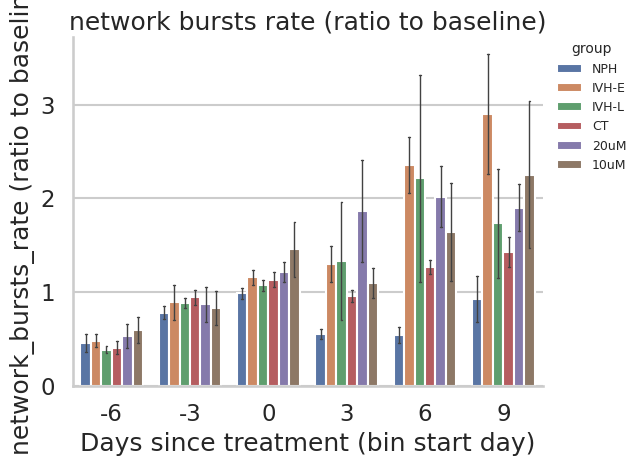

statannotations not available; annotations skipped.


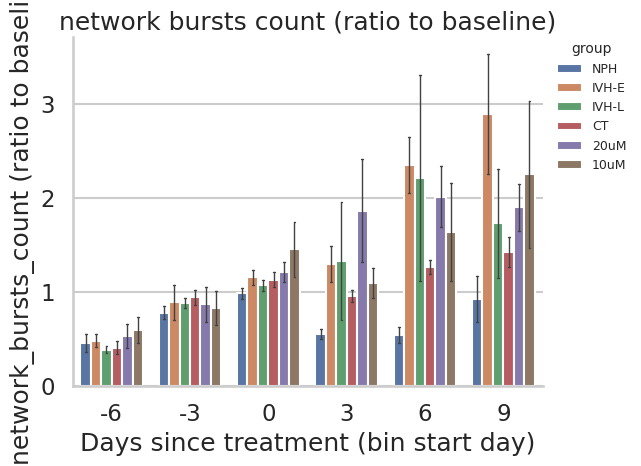

statannotations not available; annotations skipped.


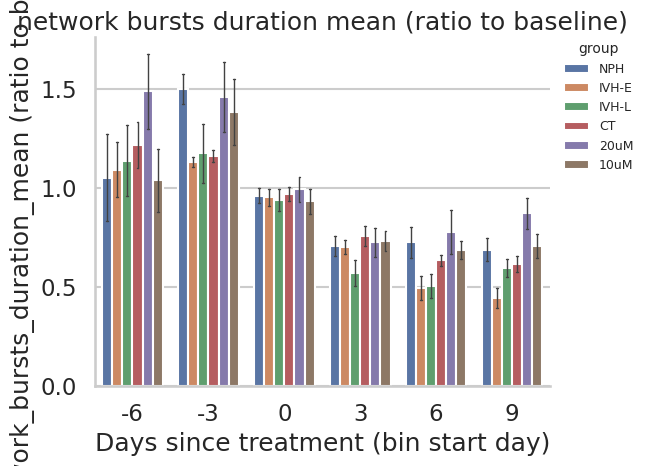

statannotations not available; annotations skipped.


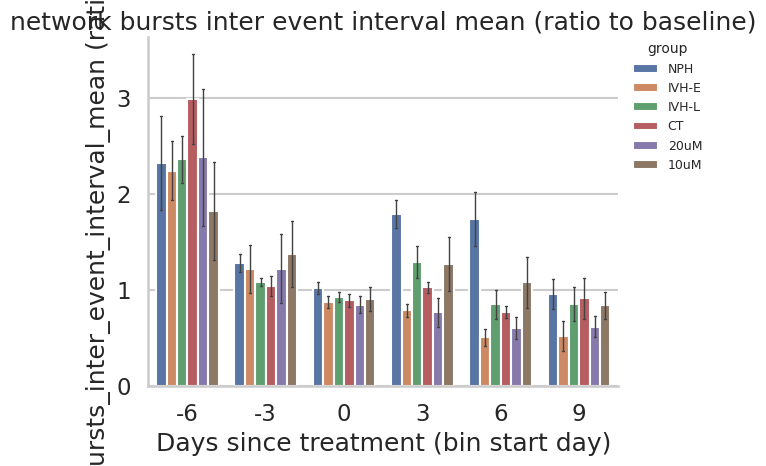

statannotations not available; annotations skipped.


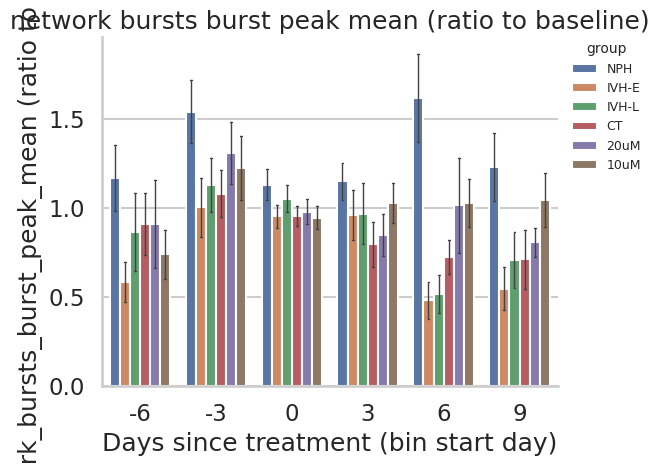

statannotations not available; annotations skipped.


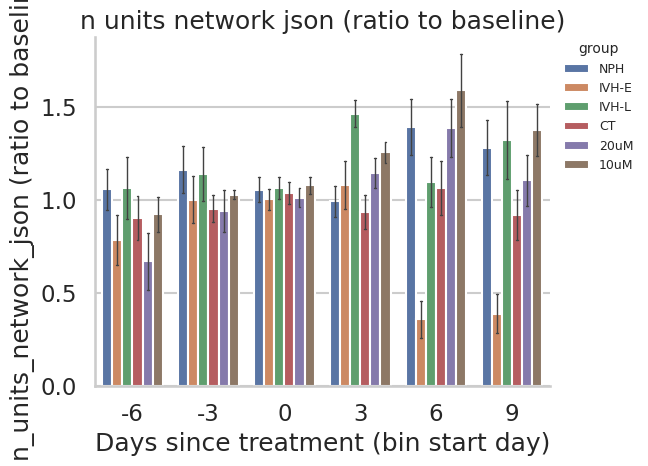

In [15]:
def _value_key(v: Any) -> str:
    if pd.isna(v):
        return 'NA'
    try:
        fv = float(v)
        if fv.is_integer():
            return str(int(fv))
        return str(fv)
    except Exception:
        return str(v)


def build_reference_annotation_inputs(
    plot_df: pd.DataFrame,
    metric: str,
    pairwise_stats_df: pd.DataFrame,
    group_col: str,
    x_col: str | None,
    reference_group: str,
    alpha: float,
    use_adjusted_p: bool,
    x_order: list[Any] | None,
) -> tuple[list[Any], list[float], pd.DataFrame]:
    if pairwise_stats_df is None or pairwise_stats_df.empty:
        return [], [], pd.DataFrame()

    ann = pairwise_stats_df.copy()
    ann = ann[(ann['test_type'] == 'welch_t') & (ann['metric'] == metric)].copy()
    if ann.empty:
        return [], [], ann

    comp = ann['comparison'].str.split(' vs ', n=1, expand=True)
    if comp.shape[1] != 2:
        return [], [], pd.DataFrame()

    ann['group_1'] = comp[0]
    ann['group_2'] = comp[1]
    ann = ann[(ann['group_1'] == reference_group) | (ann['group_2'] == reference_group)].copy()
    if ann.empty:
        return [], [], ann

    p_col = 'p_adj' if use_adjusted_p and 'p_adj' in ann.columns else 'p_value'
    ann[p_col] = pd.to_numeric(ann[p_col], errors='coerce')
    ann = ann[ann[p_col] < alpha].copy()
    if ann.empty:
        return [], [], ann

    ann['other_group'] = np.where(ann['group_1'] == reference_group, ann['group_2'], ann['group_1'])

    pairs: list[Any] = []
    pvalues: list[float] = []

    if x_col and x_col in plot_df.columns:
        x_lookup = {_value_key(x): x for x in (x_order or sorted(plot_df[x_col].dropna().unique().tolist()))}
        for _, row in ann.iterrows():
            x_key = _value_key(row['x_value'])
            if x_key not in x_lookup:
                continue

            x_val = x_lookup[x_key]
            other_group = str(row['other_group'])

            sub = plot_df[plot_df[x_col] == x_val]
            available_groups = set(sub[group_col].dropna().astype(str))
            if reference_group not in available_groups or other_group not in available_groups:
                continue

            pair = ((x_val, reference_group), (x_val, other_group))
            pval = float(row[p_col])
            pairs.append(pair)
            pvalues.append(pval)
    else:
        available_groups = set(plot_df[group_col].dropna().astype(str))
        for _, row in ann.iterrows():
            other_group = str(row['other_group'])
            if reference_group not in available_groups or other_group not in available_groups:
                continue
            pair = (reference_group, other_group)
            pval = float(row[p_col])
            pairs.append(pair)
            pvalues.append(pval)

    if not pairs:
        return [], [], ann

    best = {}
    for pair, pval in zip(pairs, pvalues):
        if pair not in best or pval < best[pair]:
            best[pair] = pval

    dedup_pairs = list(best.keys())
    dedup_pvals = [best[p] for p in dedup_pairs]
    return dedup_pairs, dedup_pvals, ann


def _apply_legend_outside(ax, fig, group_col: str, legend_cfg: dict[str, Any] | None) -> None:
    cfg = legend_cfg or {}
    if not bool(cfg.get('outside_right', True)):
        return

    legend = ax.get_legend()
    if legend is None:
        return

    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return

    legend.remove()

    bbox = cfg.get('bbox_to_anchor', (1.02, 1.0))
    if isinstance(bbox, list):
        bbox = tuple(bbox)

    ax.legend(
        handles,
        labels,
        title=group_col,
        loc=str(cfg.get('loc', 'upper left')),
        bbox_to_anchor=bbox,
        ncol=int(cfg.get('ncol', 1)),
        frameon=bool(cfg.get('frameon', False)),
        fontsize=float(cfg.get('fontsize', 9)),
        title_fontsize=float(cfg.get('title_fontsize', 10)),
        borderaxespad=0.0,
    )

    right_margin = float(cfg.get('right_margin', 0.78))
    fig.tight_layout(rect=[0.0, 0.0, right_margin, 1.0])


def plot_metric_trajectory(
    well_df: pd.DataFrame,
    metric: str,
    group_col: str,
    x_col: str | None,
    group_order: list[str] | None = None,
    palette: dict[str, str] | None = None,
    x_label: str | None = None,
    pairwise_stats_df: pd.DataFrame | None = None,
    annotation_cfg: dict[str, Any] | None = None,
    metric_display_map: dict[str, str] | None = None,
    legend_cfg: dict[str, Any] | None = None,
    stats_alpha: float = 0.05,
    print_significant: bool = False,
):
    if metric not in well_df.columns:
        print(f'Skip plot (metric missing): {metric}')
        return None, None

    cfg = annotation_cfg or {}
    display_map = metric_display_map or {}
    metric_display = display_map.get(metric, metric)

    annotation_enabled = bool(cfg.get('enabled', True))
    reference_group = str(cfg.get('reference_group', 'CT'))
    use_adjusted_p = bool(cfg.get('use_adjusted_p', True))

    cols = [metric, group_col] + ([x_col] if x_col and x_col in well_df.columns else [])
    plot_df = well_df[cols].copy()
    plot_df[metric] = pd.to_numeric(plot_df[metric], errors='coerce')
    plot_df[group_col] = plot_df[group_col].astype(str)
    plot_df = plot_df.dropna(subset=[metric, group_col])

    if plot_df.empty:
        print(f'Skip plot (no data after NA drop): {metric}')
        return None, None

    fig, ax = plt.subplots(figsize=(9, 5))

    x_order = None
    if x_col and x_col in plot_df.columns:
        plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors='coerce')
        plot_df = plot_df.dropna(subset=[x_col])
        if plot_df.empty:
            print(f'Skip plot (x-axis empty after NA drop): {metric}')
            plt.close(fig)
            return None, None

        x_order = sorted(plot_df[x_col].unique().tolist())

        sns.barplot(
            data=plot_df,
            x=x_col,
            y=metric,
            hue=group_col,
            order=x_order,
            hue_order=group_order,
            palette=palette,
            estimator='mean',
            errorbar='se',
            capsize=0.15,
            err_kws={'linewidth': 1},
            ax=ax,
        )
        ax.set_xlabel(x_label if x_label else x_col)
        tick_positions = np.arange(len(x_order), dtype=float)
        tick_labels = [str(int(x)) if float(x).is_integer() else f'{x:.1f}' for x in x_order]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
    else:
        sns.barplot(
            data=plot_df,
            x=group_col,
            y=metric,
            order=group_order,
            palette=palette,
            estimator='mean',
            errorbar='se',
            capsize=0.15,
            err_kws={'linewidth': 1},
            ax=ax,
        )
        ax.set_xlabel(group_col)

    if annotation_enabled and Annotator is not None and pairwise_stats_df is not None and not pairwise_stats_df.empty:
        pairs, pvalues, ann_rows = build_reference_annotation_inputs(
            plot_df=plot_df,
            metric=metric,
            pairwise_stats_df=pairwise_stats_df,
            group_col=group_col,
            x_col=x_col,
            reference_group=reference_group,
            alpha=stats_alpha,
            use_adjusted_p=use_adjusted_p,
            x_order=x_order,
        )

        if pairs:
            if x_col and x_col in plot_df.columns:
                annotator = Annotator(
                    ax,
                    pairs,
                    data=plot_df,
                    x=x_col,
                    y=metric,
                    hue=group_col,
                    order=x_order,
                    hue_order=group_order,
                )
            else:
                annotator = Annotator(
                    ax,
                    pairs,
                    data=plot_df,
                    x=group_col,
                    y=metric,
                    order=group_order,
                )

            annotator.configure(
                test=None,
                text_format=str(cfg.get('text_format', 'star')),
                loc=str(cfg.get('loc', 'outside')),
                fontsize=float(cfg.get('fontsize', 9)),
                comparisons_correction=None,
                verbose=0,
            )
            annotator.set_pvalues_and_annotate(pvalues)

            if print_significant:
                print(f'Significant {reference_group} comparisons for {metric_display} (alpha={stats_alpha}): {len(pairs)}')
                show = ann_rows.copy()
                show_cols = [
                    c for c in [
                        'x_value',
                        'comparison',
                        'other_group',
                        'statistic',
                        'p_value',
                        'p_adj',
                        'effect_size',
                    ]
                    if c in show.columns
                ]
                display(show[show_cols].sort_values(['x_value', 'other_group']).head(50))
        elif print_significant:
            print(f'No significant {reference_group} comparisons to annotate for {metric_display}.')
    elif annotation_enabled and Annotator is None:
        print('statannotations not available; annotations skipped.')

    ax.set_title(metric_display.replace('_', ' '))
    ax.set_ylabel(metric_display)
    sns.despine(ax=ax)

    _apply_legend_outside(ax, fig, group_col=group_col, legend_cfg=legend_cfg)

    return fig, ax


preview_metrics = available_metrics[: min(6, len(available_metrics))]
for metric in preview_metrics:
    fig, _ = plot_metric_trajectory(
        analysis_well_level,
        metric=metric,
        group_col=analysis_cfg['group_col'],
        x_col=x_col,
        group_order=analysis_cfg['group_order'],
        palette=analysis_cfg['palette'],
        x_label=analysis_cfg.get('x_label'),
        pairwise_stats_df=pairwise_stats,
        annotation_cfg=annotation_cfg,
        metric_display_map=metric_display_name_map,
        legend_cfg=analysis_cfg.get('legend', {}),
        stats_alpha=stats_alpha,
        print_significant=True,
    )
    if fig is not None:
        plt.show()


In [16]:
output_dir = Path(CONFIG['output_dir']).expanduser().resolve()
fig_dir = output_dir / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

well_manifest.to_csv(output_dir / 'well_manifest_discovered.csv', index=False)
well_index.to_csv(output_dir / 'well_index_with_annotations.csv', index=False)
well_filtered.to_csv(output_dir / 'well_filtered.csv', index=False)
exclusion_log.to_csv(output_dir / 'exclusion_log.csv', index=False)

network_metrics_well.to_csv(output_dir / 'network_metrics_well_raw.csv', index=False)
unit_metrics_raw.to_csv(output_dir / 'unit_metrics_raw.csv', index=False)
template_metrics_raw.to_csv(output_dir / 'template_metrics_raw.csv', index=False)

unit_agg_well.to_csv(output_dir / 'unit_metrics_aggregated_to_well.csv', index=False)
template_agg_well.to_csv(output_dir / 'template_metrics_aggregated_to_well.csv', index=False)
well_level_filtered.to_csv(output_dir / 'well_level_filtered_merged.csv', index=False)
normalized_well_level.to_csv(output_dir / 'well_level_normalized.csv', index=False)
baseline_table.to_csv(output_dir / 'baseline_table.csv', index=False)
baseline_rows_selected.to_csv(output_dir / 'baseline_rows_selected.csv', index=False)
normalization_qc.to_csv(output_dir / 'normalization_qc.csv', index=False)
analysis_well_level.to_csv(output_dir / 'analysis_well_level_for_stats.csv', index=False)

group_summary_long.to_csv(output_dir / 'group_summary_long.csv', index=False)
pairwise_stats.to_csv(output_dir / 'pairwise_stats.csv', index=False)
significant_stats.to_csv(output_dir / 'significant_stats.csv', index=False)
ct_significant_stats.to_csv(output_dir / 'ct_significant_stats.csv', index=False)

excel_path = output_dir / 'cohort_analysis_tables.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    well_manifest.to_excel(writer, sheet_name='well_manifest', index=False)
    well_index.to_excel(writer, sheet_name='well_index', index=False)
    well_filtered.to_excel(writer, sheet_name='well_filtered', index=False)
    exclusion_log.to_excel(writer, sheet_name='exclusion_log', index=False)
    network_metrics_well.to_excel(writer, sheet_name='network_metrics_well', index=False)
    unit_agg_well.to_excel(writer, sheet_name='unit_agg_well', index=False)
    template_agg_well.to_excel(writer, sheet_name='template_agg_well', index=False)
    well_level_filtered.to_excel(writer, sheet_name='well_level_filtered', index=False)
    normalized_well_level.to_excel(writer, sheet_name='well_level_normalized', index=False)
    baseline_table.to_excel(writer, sheet_name='baseline_table', index=False)
    baseline_rows_selected.to_excel(writer, sheet_name='baseline_rows_selected', index=False)
    normalization_qc.to_excel(writer, sheet_name='normalization_qc', index=False)
    analysis_well_level.to_excel(writer, sheet_name='analysis_well_level', index=False)
    group_summary_long.to_excel(writer, sheet_name='group_summary', index=False)
    pairwise_stats.to_excel(writer, sheet_name='pairwise_stats', index=False)
    significant_stats.to_excel(writer, sheet_name='significant_stats', index=False)
    ct_significant_stats.to_excel(writer, sheet_name='ct_significant_stats', index=False)

for metric in available_metrics:
    fig, _ = plot_metric_trajectory(
        analysis_well_level,
        metric=metric,
        group_col=analysis_cfg['group_col'],
        x_col=x_col,
        group_order=analysis_cfg['group_order'],
        palette=analysis_cfg['palette'],
        x_label=analysis_cfg.get('x_label'),
        pairwise_stats_df=pairwise_stats,
        annotation_cfg=annotation_cfg,
        metric_display_map=metric_display_name_map,
        legend_cfg=analysis_cfg.get('legend', {}),
        stats_alpha=stats_alpha,
        print_significant=False,
    )
    if fig is None:
        continue
    fig.savefig(fig_dir / f'{metric}_barplot.svg', dpi=300, bbox_inches='tight')
    fig.savefig(fig_dir / f'{metric}_barplot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

print(f'Export complete: {output_dir}')
print(f'Figure export:   {fig_dir}')
print(f'Excel export:    {excel_path}')


statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
statannotations not available; annotations skipped.
Export complete: /mnt/Vol20tb1/yuxin/codes/Yuxin_Fork/IPNAnalysis/workbooks/analysis_outputs
Figure export:   /mnt/Vol20tb1/yuxin/codes/Yuxin_Fork/IPNAnalysis/workbooks/analysis_outputs/figures
Excel export:    /mnt/Vol20tb1/yuxin/codes/Yuxin_Fork/IPNAnalysis/workbooks/analysis_outputs/cohort_analysis_tables.xlsx


## Next Step
When you are ready, we can add a reference-sheet loader cell (`metadata`, `group_map`, `outliers`) that feeds the same filtering and aggregation pipeline used here.
